<a href="https://colab.research.google.com/github/Nnataliyay/icETRAN-2026/blob/main/Ispit_Correlation_Analysis_of_Indoor_Outdoor_Air_Pollutants_in_Residential_Microenvironments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Osnovne informacije o Datasetu i podacima
  * podaci su podeljeni po:

      - lokaciji (room1, room2, outdoor)
      - vremenskoj agregaciji (hourly, daily)
      - tipu podataka (raw, qc, mask)

  * A) RAW / osnovni podaci
      - room1_hourly.csv
      - room2_hourly.csv
      - outdoor_hourly.csv

  * B) QC fajlovi (Quality Control)
      - room1_hourly_qc.csv
      - room2_hourly_qc.csv
      - outdoor_hourly_qc.csv
      - room1_daily_qc.csv
      - room2_daily_qc.csv
      - outdoor_daily_qc.csv

  * C) MASK fajlovi (maska validnosti podataka True/False) - Mask je rezultat svih QC pravila zajedno.
      - room1_mask.csv
      - room2_mask.csv
      - outdoor_mask.csv

Dodari nacin obrade outliera
Metodologija o tome stasmo koristili za analizu
Materials and methods
QC kako tretirati outliere
Chapter o formulama, kodu
Results of research

uvod, metode(ovde i dataset info, sampling size equipments, site, when, what 2 periods - izabrali reprezentativni deo, what was used for tech or data fixing, what corr, data overview poglavlje, dodatan period povecane aktivnosti dodat),
rezultati results and discussion()
i zaključak

300dpi kvalitet slike#Osnovne informacije o Datasetu i podacima
  * podaci su podeljeni po:

      - lokaciji (room1, room2, outdoor)
      - vremenskoj agregaciji (hourly, daily)
      - tipu podataka (raw, qc, mask)

  * A) RAW / osnovni podaci
      - room1_hourly.csv
      - room2_hourly.csv
      - outdoor_hourly.csv

  * B) QC fajlovi (Quality Control)
      - room1_hourly_qc.csv
      - room2_hourly_qc.csv
      - outdoor_hourly_qc.csv
      - room1_daily_qc.csv
      - room2_daily_qc.csv
      - outdoor_daily_qc.csv

  * C) MASK fajlovi (maska validnosti podataka True/False) - Mask je rezultat svih QC pravila zajedno.
      - room1_mask.csv
      - room2_mask.csv
      - outdoor_mask.csv

Dodari nacin obrade outliera
Metodologija o tome stasmo koristili za analizu
Materials and methods
QC kako tretirati outliere
Chapter o formulama, kodu
Results of research

uvod, metode(ovde i dataset info, sampling size equipments, site, when, what 2 periods - izabrali reprezentativni deo, what was used for tech or data fixing, what corr, data overview poglavlje, dodatan period povecane aktivnosti dodat),
rezultati results and discussion()
i zaključak

300dpi kvalitet slike

# Dataset overview

Upoznavanje room1_daily.csv room2_daily.csv
!!! Iz nekog razloga nemamo room1_daily.csv , room2_daily.csv

Upoznavanje room2_hourly.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Statisticka analiza - ide u methods

In [ ]:
df_room1 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')

print("Columns:", df_room1.columns.tolist())

display(df_room1.describe())

Columns: ['TIME', 'T', 'RH', 'P', 'PM1', 'PM2.5', 'PM10', 'CO2', 'VOC']


,T,RH,P,PM1,PM2.5,PM10,CO2,VOC
count,1609.000000,1609.000000,1609.000000,1609.000000,1609.000000,1609.000000,1609.000000,1609.000000
mean,30.232209,44.333676,1006.902553,7.839008,11.628914,13.447863,790.994288,106.149776
std,1.203499,3.590056,4.335467,8.313354,13.841972,16.424559,432.404649,66.179324
min,25.195000,30.984833,994.120500,0.000000,0.000000,0.000000,347.183333,0.000000
25%,29.424333,42.721167,1003.860000,2.000000,2.633333,3.000000,459.750000,69.066667
50%,30.306667,44.562500,1007.446000,5.000000,6.483333,7.250000,593.650000,99.000000
75%,30.971000,45.963333,1010.193500,10.750000,15.433333,17.233333,1025.850000,123.666667
max,33.240000,59.765000,1015.520000,84.550000,157.583333,174.516667,2633.250000,479.966667


In [ ]:
df_room2 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

display(df_room2.describe())

,T,RH,P,PM1,PM2_5,PM10,CO2,VOC
count,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000
mean,29.535409,46.114226,1006.702198,9.533129,13.749267,15.371704,1063.046601,129.078818
std,1.535558,4.546205,4.344009,9.853053,15.537697,17.972309,795.088895,81.565078
min,24.099000,28.429500,993.999333,0.000000,0.000000,0.000000,384.000000,0.000000
25%,28.399667,44.265625,1003.681250,2.250000,2.750000,3.137500,469.520833,84.012500
50%,29.675417,44.870000,1007.166500,6.083333,7.816667,8.333333,729.175000,105.666667
75%,30.431875,48.581292,1009.958500,13.550000,19.104167,20.362500,1461.112218,154.629167
max,33.240000,61.668333,1015.520000,94.050000,160.183333,173.600000,5356.466667,481.166667


In [ ]:
df_outdoor = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/outdoor_hourly.csv')

display(df_outdoor.describe())

,T,RH,P,PM1,PM2.5,PM10,CO2,VOC
count,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,0.0
mean,31.117926,40.415802,1006.084181,9.710479,13.116453,14.150479,622.959684,NaN
std,8.746335,20.246547,4.084002,7.225875,10.825198,12.263332,156.217080,NaN
min,16.636500,5.763500,993.440000,0.050000,0.300000,0.366667,1.483333,NaN
25%,24.312375,22.033875,1003.431875,4.504167,5.708333,6.041667,500.129167,NaN
50%,28.563750,40.726250,1006.598500,8.211111,10.375000,11.000000,621.782624,NaN
75%,37.261917,55.667167,1008.934542,13.025000,17.250000,18.062500,753.116667,NaN
max,55.939833,97.980000,1013.955333,64.966667,102.333333,107.116667,966.116667,NaN


# Dataset QC

## Room 1

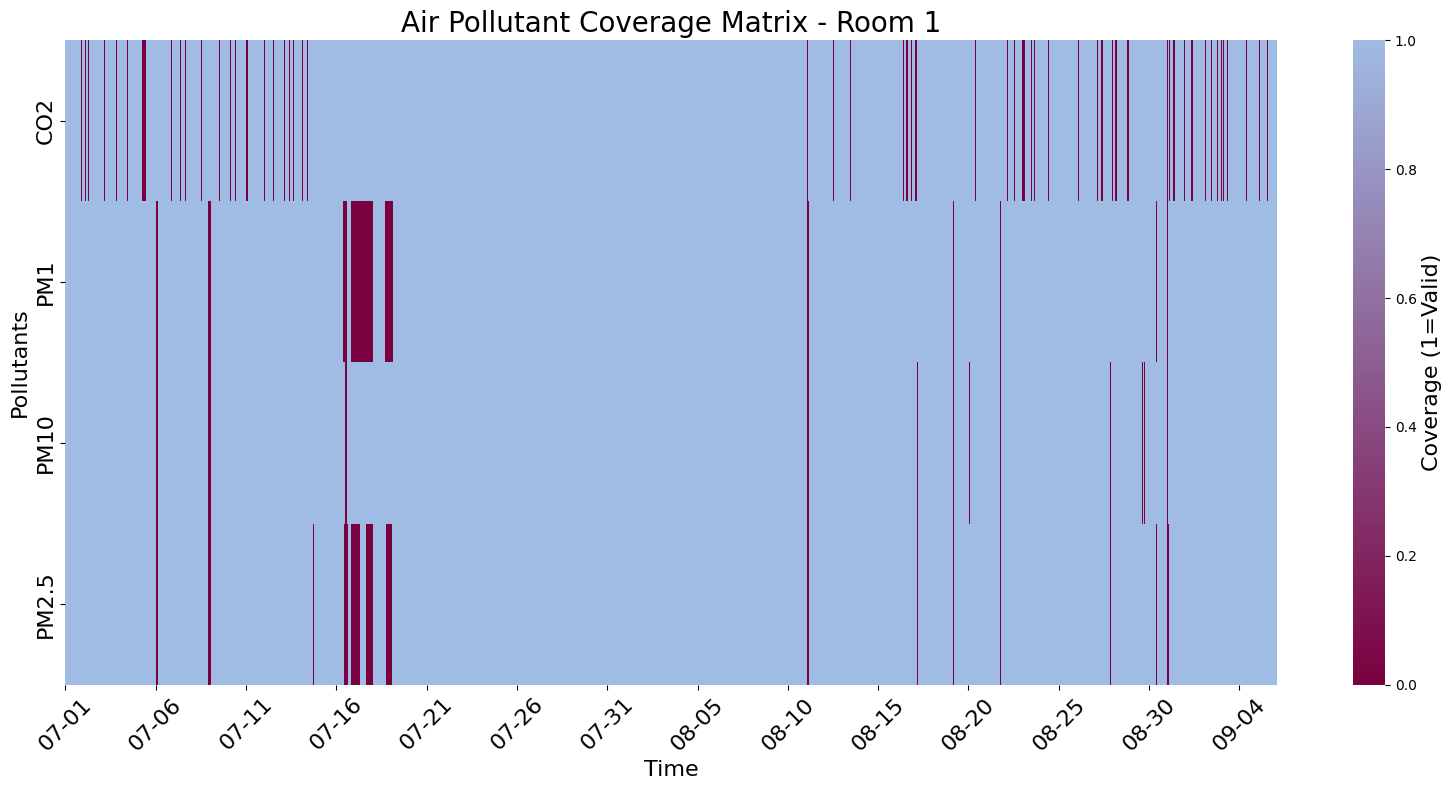

In [ ]:
df_room1_qc = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly_qc.csv')
df_room1_qc['TIME'] = pd.to_datetime(df_room1_qc['TIME'])

valid_cols = [col for col in df_room1_qc.columns if col.endswith('_n_valid') and 'VOC' not in col and 'RH' not in col and 'T' not in col and col != 'P_n_valid']

matrix_data = df_room1_qc[['TIME'] + valid_cols].melt(id_vars='TIME', var_name='pollutant', value_name='is_valid')
matrix_data['pollutant'] = matrix_data['pollutant'].str.replace('_n_valid', '')

matrix = matrix_data.pivot(index='pollutant', columns='TIME', values='is_valid')
matrix_hourly = matrix.T.resample('h').mean().T

custom_cmap = LinearSegmentedColormap.from_list("custom_palette", ["#7A003F", "#A0BBE4"])

plt.figure(figsize=(16, 8))
ax = sns.heatmap(matrix_hourly, cmap=custom_cmap, cbar_kws={'label': 'Coverage (1=Valid)'})
cax = ax.collections[0].colorbar.ax
cax.yaxis.label.set_size(16)
x_labels = [t.strftime('%m-%d') for t in matrix_hourly.columns]
n = 120
ax.set_xticks(range(0, len(x_labels), n))
ax.set_xticklabels(x_labels[::n], rotation=45, fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

plt.title('Air Pollutant Coverage Matrix - Room 1', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Pollutants', fontsize=16)
plt.tight_layout()
plt.show()

Traženje najvećeg perioda bez nevalidnih merenja

In [ ]:
def find_longest_valid_period(data):
    valid_cols = [col for col in data.columns if col.endswith('_n_valid') and ('PM' in col or 'CO2' in col)]

    is_perfect = (data[valid_cols] == 1.0).all(axis=1)

    blocks = (is_perfect != is_perfect.shift()).cumsum()

    valid_blocks = blocks[is_perfect]

    if valid_blocks.empty:
        return None, None, 0

    longest_block_id = valid_blocks.value_counts().idxmax()

    perfect_times = data.loc[valid_blocks[valid_blocks == longest_block_id].index, 'TIME']

    start = perfect_times.min()
    end = perfect_times.max()
    duration = len(perfect_times)

    return start, end, duration, valid_cols

start, end, duration, filtered_cols = find_longest_valid_period(df_room1_qc)

if start:
    print(f"--- Longest Continuous Period of 100% Validity ---")
    print(f"Columns considered: {', '.join([c.replace('_n_valid','') for c in filtered_cols])}")
    print(f"Start:    {start}")
    print(f"End:      {end}")
    print(f"Duration: {duration} hours")
else:
    print("No periods found where all selected pollutants were 100% valid.")

--- Longest Continuous Period of 100% Validity ---
Columns considered: PM1, PM2.5, PM10, CO2
Start:    2025-07-20 01:00:00
End:      2025-08-11 23:00:00
Duration: 551 hours


## Room 2

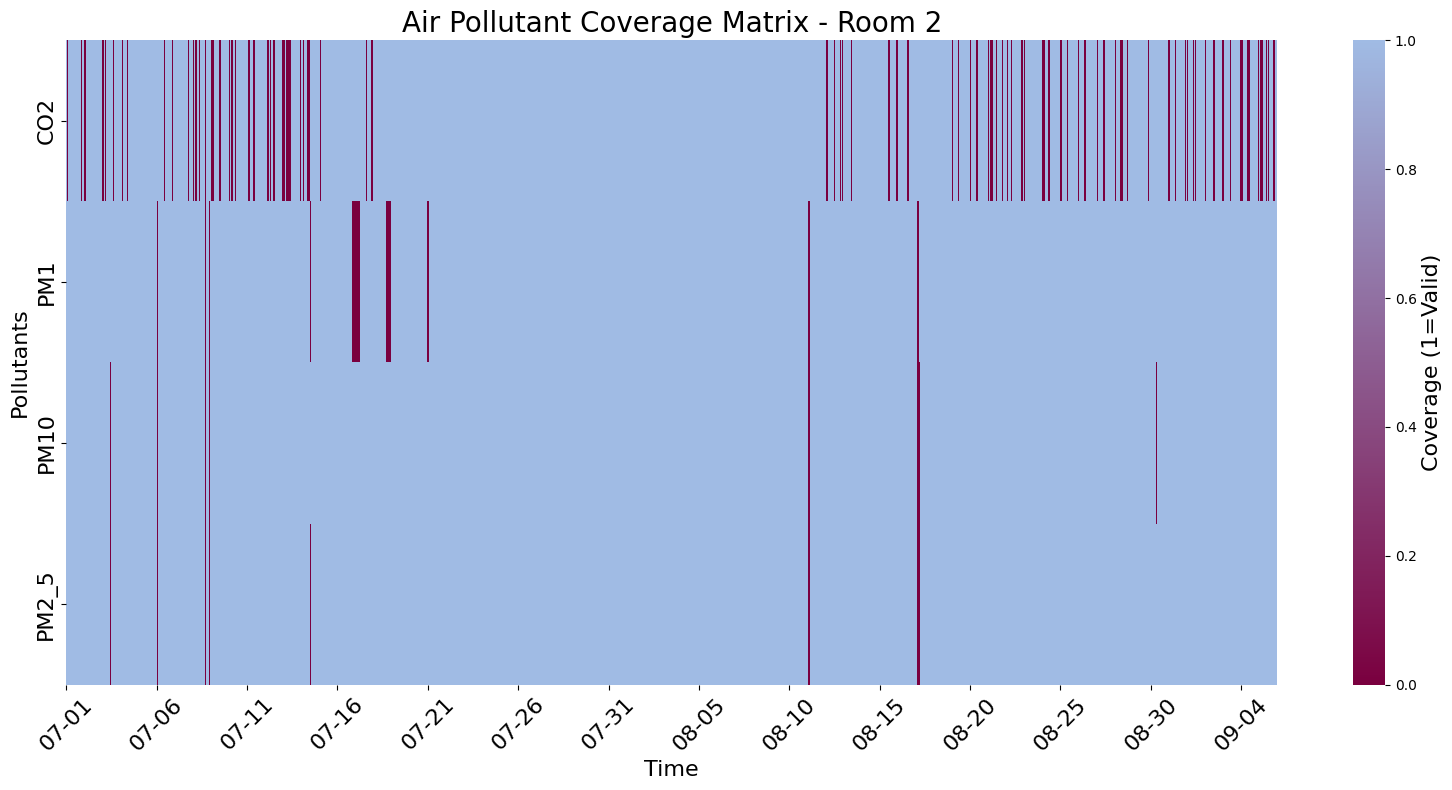

In [ ]:
df_room2_qc = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly_qc.csv')
df_room2_qc['TIME'] = pd.to_datetime(df_room2_qc['TIME'])

valid_cols = [col for col in df_room2_qc.columns if col.endswith('_n_valid') and 'VOC' not in col and 'RH' not in col and 'T' not in col and col != 'P_n_valid']

matrix_data = df_room2_qc[['TIME'] + valid_cols].melt(id_vars='TIME', var_name='pollutant', value_name='is_valid')
matrix_data['pollutant'] = matrix_data['pollutant'].str.replace('_n_valid', '')

matrix = matrix_data.pivot(index='pollutant', columns='TIME', values='is_valid')
matrix_hourly = matrix.T.resample('h').mean().T

plt.figure(figsize=(16, 8))
ax = sns.heatmap(matrix_hourly, cmap=custom_cmap, cbar_kws={'label': 'Coverage (1=Valid)'})
cax = ax.collections[0].colorbar.ax
cax.yaxis.label.set_size(16)
x_labels = [t.strftime('%m-%d') for t in matrix_hourly.columns]
n = 120
ax.set_xticks(range(0, len(x_labels), n))
ax.set_xticklabels(x_labels[::n], rotation=45, fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

plt.title('Air Pollutant Coverage Matrix - Room 2', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Pollutants', fontsize=16)
plt.tight_layout()
plt.show()

Traženje najvećeg perioda bez nevalidnih merenja

In [ ]:
def find_longest_valid_period(data):
    valid_cols = [col for col in data.columns if col.endswith('_n_valid') and ('PM' in col or 'CO2' in col)]
    is_perfect = (data[valid_cols] == 1.0).all(axis=1)
    blocks = (is_perfect != is_perfect.shift()).cumsum()

    valid_blocks = blocks[is_perfect]

    if valid_blocks.empty:
        return None, None, 0, valid_cols

    longest_block_id = valid_blocks.value_counts().idxmax()

    perfect_times = data.loc[valid_blocks[valid_blocks == longest_block_id].index, 'TIME']

    start = perfect_times.min()
    end = perfect_times.max()
    duration = len(perfect_times)

    return start, end, duration, valid_cols


start, end, duration, filtered_cols = find_longest_valid_period(df_room2_qc)

if start:
    print(f"--- Longest Continuous Period of 100% Validity (ROOM 2) ---")
    print(f"Columns considered: {', '.join([c.replace('_n_valid','') for c in filtered_cols])}")
    print(f"Start:    {start}")
    print(f"End:      {end}")
    print(f"Duration: {duration} hours")
else:
    print("No periods found where all selected pollutants were 100% valid in Room 2.")

--- Longest Continuous Period of 100% Validity (ROOM 2) ---
Columns considered: PM1, PM2_5, PM10, CO2
Start:    2025-07-21 23:00:00
End:      2025-08-11 21:00:00
Duration: 503 hours


## Outdoor

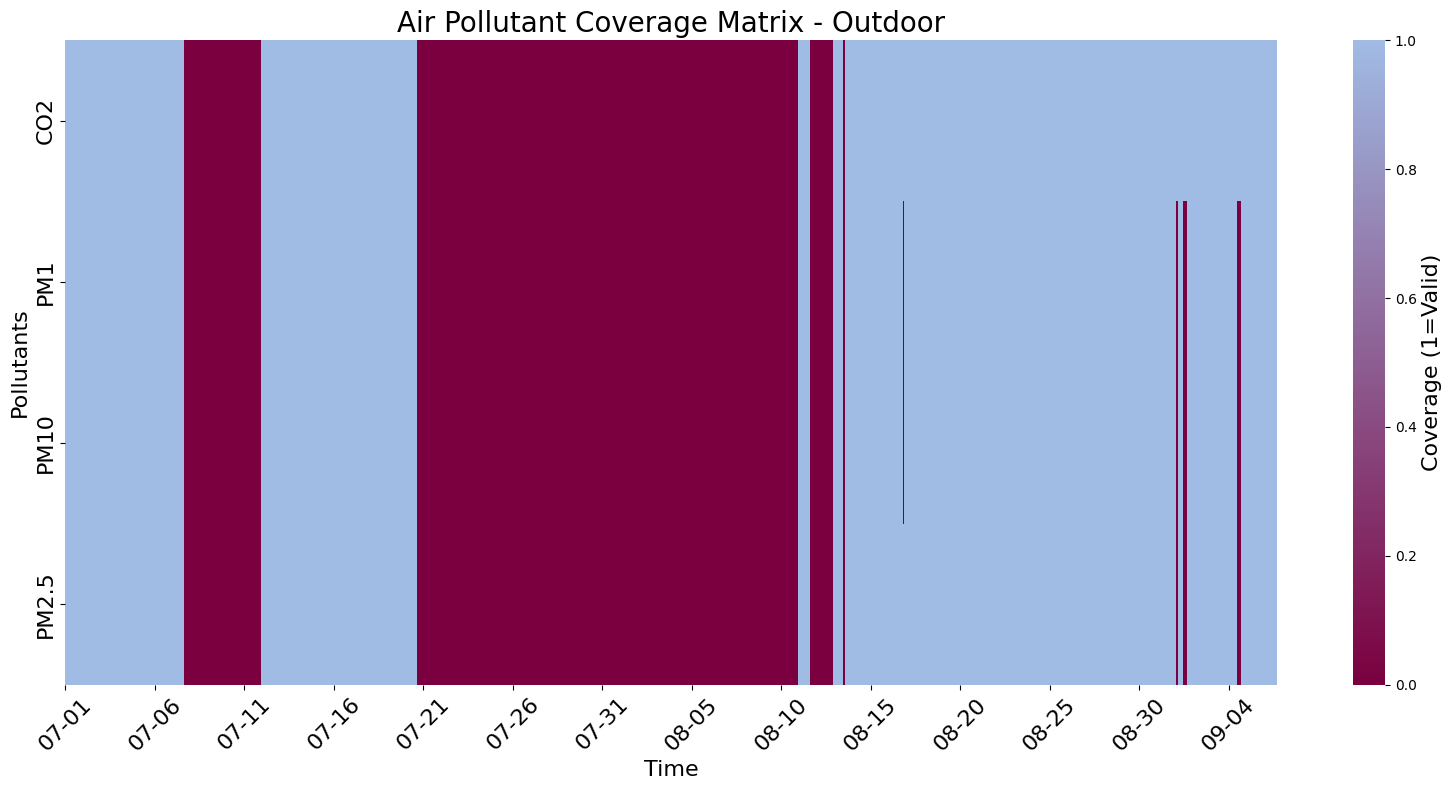

In [ ]:
df_outdoor_qc = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/outdoor_hourly_qc.csv')
df_outdoor_qc['TIME'] = pd.to_datetime(df_outdoor_qc['TIME']).dt.floor('h')

valid_cols = [col for col in df_outdoor_qc.columns if col.endswith('_n_valid') and 'VOC' not in col and 'RH' not in col and 'T' not in col and col != 'P_n_valid']

matrix_data = df_outdoor_qc[['TIME'] + valid_cols].melt(id_vars='TIME', var_name='pollutant', value_name='is_valid')
matrix_data['pollutant'] = matrix_data['pollutant'].str.replace('_n_valid', '')

matrix = matrix_data.pivot(index='pollutant', columns='TIME', values='is_valid')
matrix_hourly = matrix.T.resample('h').mean().T

plt.figure(figsize=(16, 8))
ax = sns.heatmap(matrix_hourly, cmap=custom_cmap, cbar_kws={'label': 'Coverage (1=Valid)'})
cax = ax.collections[0].colorbar.ax
cax.yaxis.label.set_size(16)
x_labels = [t.strftime('%m-%d') for t in matrix_hourly.columns]
n = 120
ax.set_xticks(range(0, len(x_labels), n))
ax.set_xticklabels(x_labels[::n], rotation=45, fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

plt.title('Air Pollutant Coverage Matrix - Outdoor', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Pollutants', fontsize=16)
plt.tight_layout()
plt.show()

peprocessing je uradjen zbog kontrole kvaliteta - pre rezultata

# Value Graphs

## Room 1

CO2

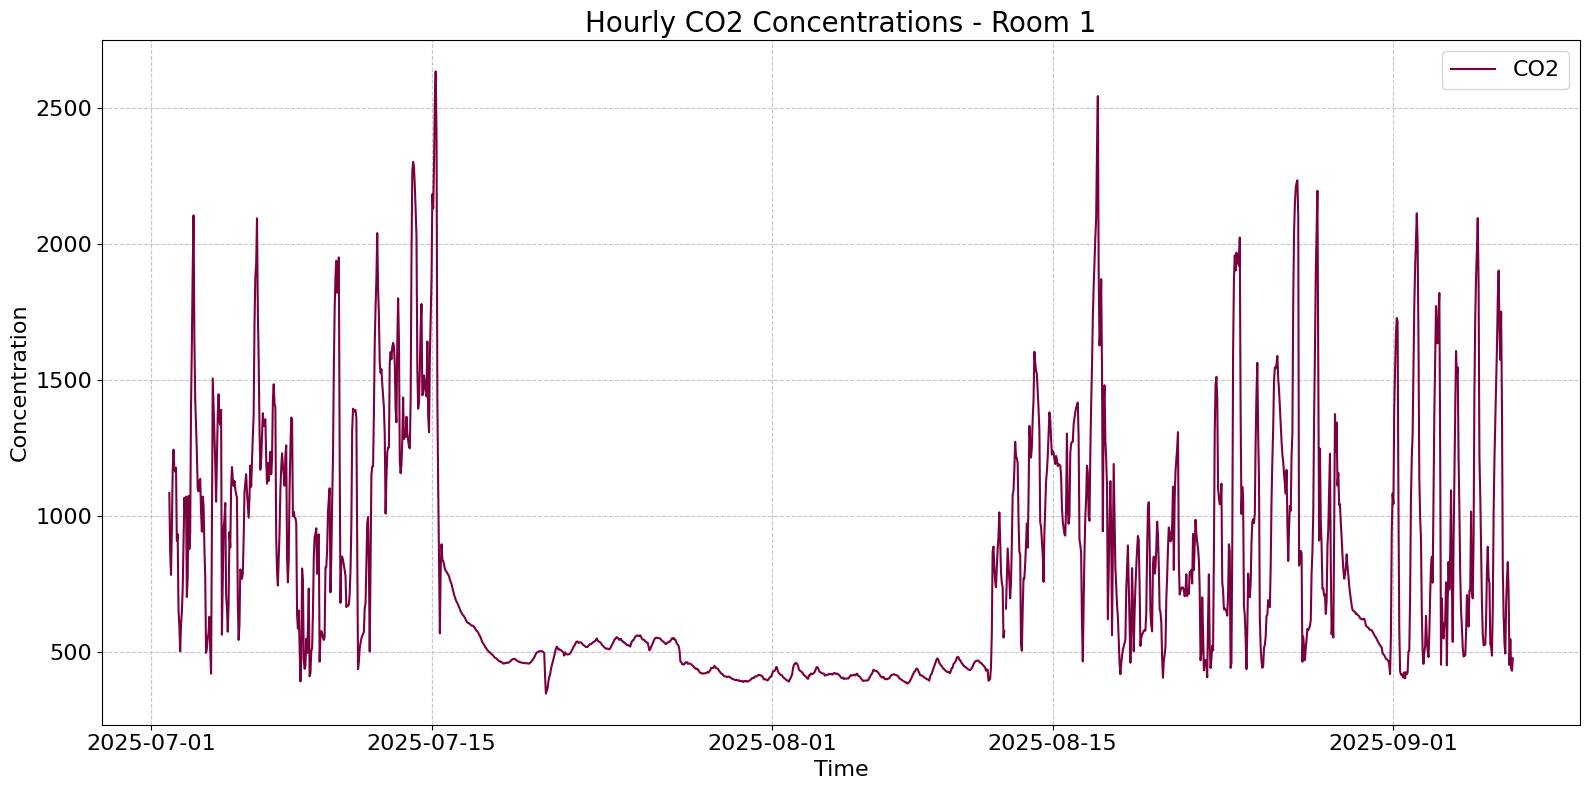

In [ ]:
df_room1['TIME'] = pd.to_datetime(df_room1['TIME'])

plot_cols = ['CO2']

plt.figure(figsize=(16, 8))
for col in plot_cols:
    if col in df_room1.columns:
        plt.plot(df_room1['TIME'], df_room1[col], label=col, color='#7A003F')

plt.title('Hourly CO2 Concentrations - Room 1', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Concentration', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Particullate Matter

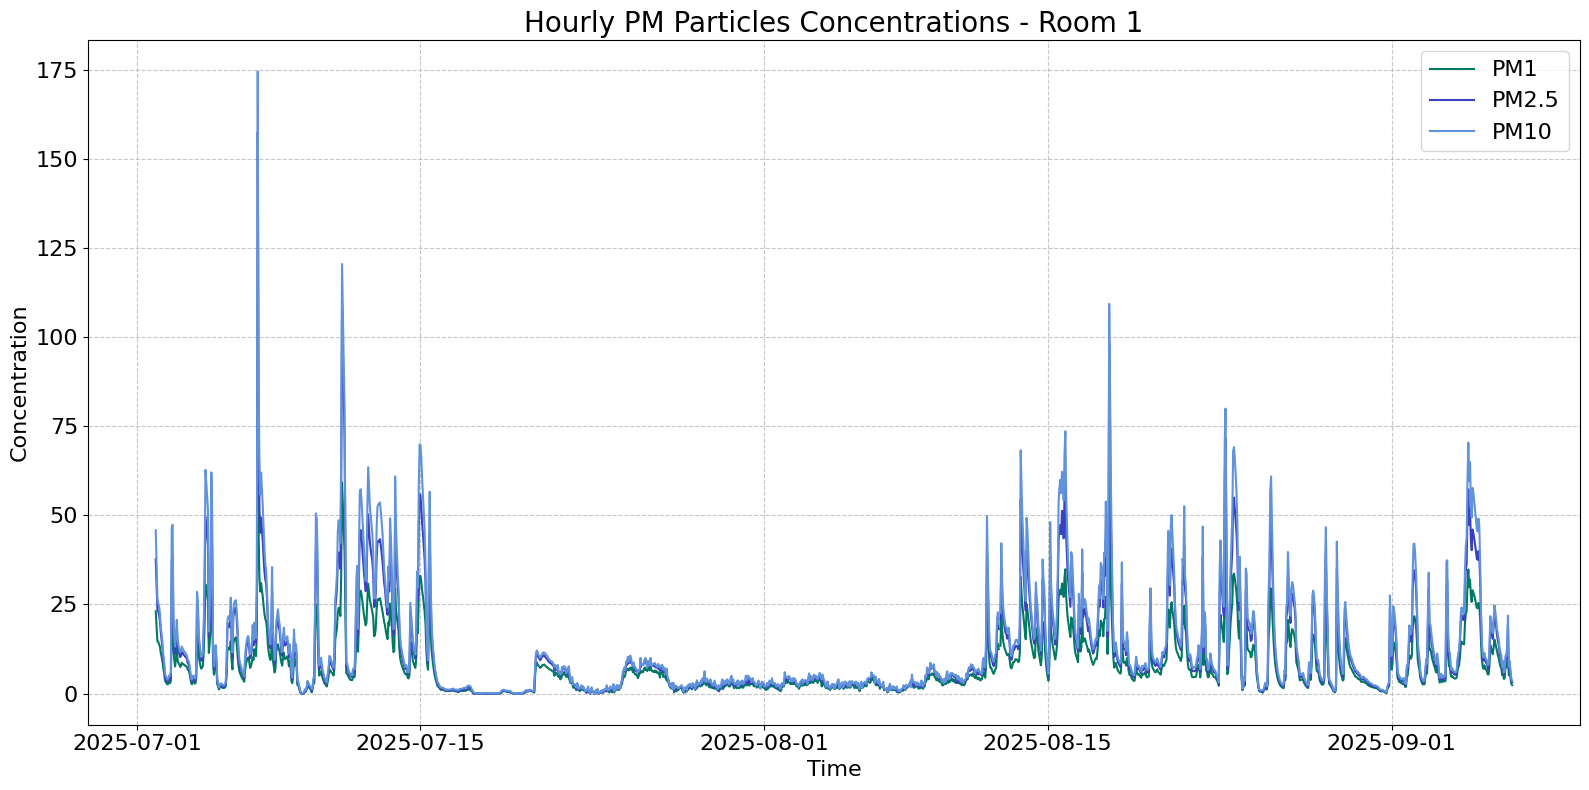

In [ ]:
df_room1['TIME'] = pd.to_datetime(df_room1['TIME'])

pm_colors = {
    'PM1': '#007A62',
    'PM2.5': '#3A41BF',
    'PM10': '#6192DC'
}
plot_cols = ['PM1', 'PM2.5', 'PM10']

plt.figure(figsize=(16, 8))
for col in plot_cols:
    if col in df_room1.columns:
        plt.plot(df_room1['TIME'], df_room1[col], label=col, color=pm_colors[col])

plt.title('Hourly PM Particles Concentrations - Room 1', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Concentration', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Combined values on 2 seperate scales

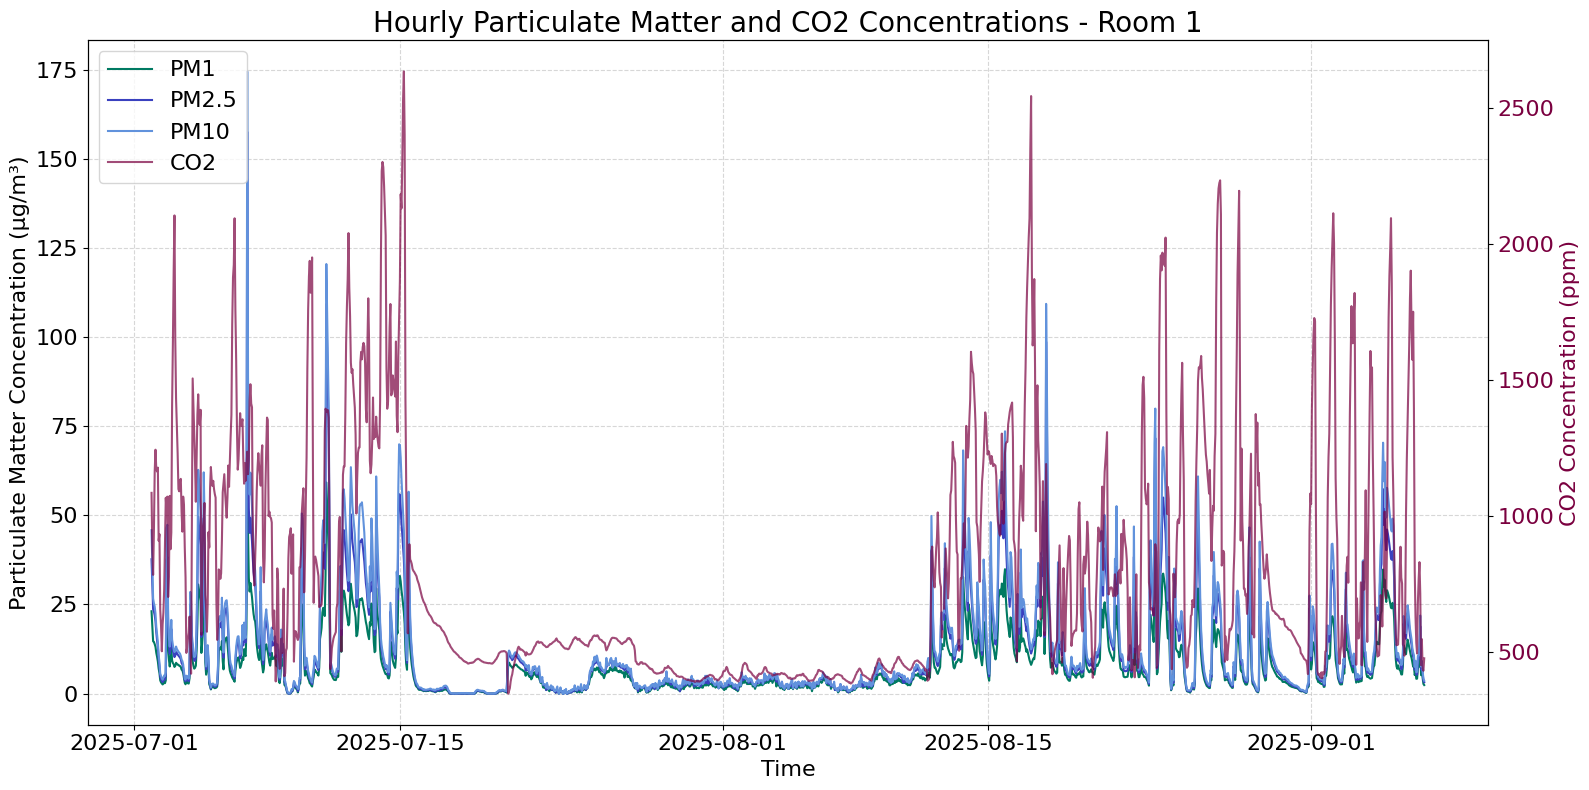

--------------------------------------------------
Period of Inactivity: 2025-07-20 01:00 to 2025-08-11 23:00
--------------------------------------------------


In [ ]:
df_room1 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df_room1['TIME'] = pd.to_datetime(df_room1['TIME'])

df_room1_qc = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly_qc.csv')
df_room1_qc['TIME'] = pd.to_datetime(df_room1_qc['TIME']).dt.floor('h')

valid_cols = [col for col in df_qc1.columns if col.endswith('_n_valid') and ('PM' in col or 'CO2' in col)]
is_perfect = (df_room1_qc[valid_cols] == 1.0).all(axis=1)
blocks = (is_perfect != is_perfect.shift()).cumsum()
valid_blocks = blocks[is_perfect]

inactivity_text = "Period of Inactivity: Not detected"
if not valid_blocks.empty:
    longest_block_id = valid_blocks.value_counts().idxmax()
    perfect_times = df_room1_qc.loc[valid_blocks[valid_blocks == longest_block_id].index, 'TIME']
    start_dt = perfect_times.min()
    end_dt = perfect_times.max()
    inactivity_text = f"Period of Inactivity: {start_dt.strftime('%Y-%m-%d %H:%M')} to {end_dt.strftime('%Y-%m-%d %H:%M')}"

fig, ax1 = plt.subplots(figsize=(16, 8))

pm_colors = {'PM1': '#007A62', 'PM2.5': '#3A41BF', 'PM10': '#6192DC'}
pm_cols = ['PM1', 'PM2.5', 'PM10']
for col in pm_cols:
    if col in df_room1.columns:
        ax1.plot(df_room1['TIME'], df_room1[col], label=col, color=pm_colors[col])
ax1.set_xlabel('Time', fontsize=16)
ax1.set_ylabel('Particulate Matter Concentration (µg/m³)', color='black', fontsize=16)
ax1.tick_params(axis='y', labelcolor='black', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
if 'CO2' in df_room1.columns:
    ax2.plot(df_room1['TIME'], df_room1['CO2'], label='CO2', color='#7A003F', alpha=0.7)
ax2.set_ylabel('CO2 Concentration (ppm)', color='#7A003F', fontsize=16)
ax2.tick_params(axis='y', labelcolor='#7A003F', labelsize=16)

plt.title('Hourly Particulate Matter and CO2 Concentrations - Room 1', fontsize=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=16)

fig.tight_layout()
plt.show()

print("-" * 50)
print(inactivity_text)
print("-" * 50)

Dodati srednju vrednost, medijanu, devijaciju, 95 percentile

## Room 2

CO2

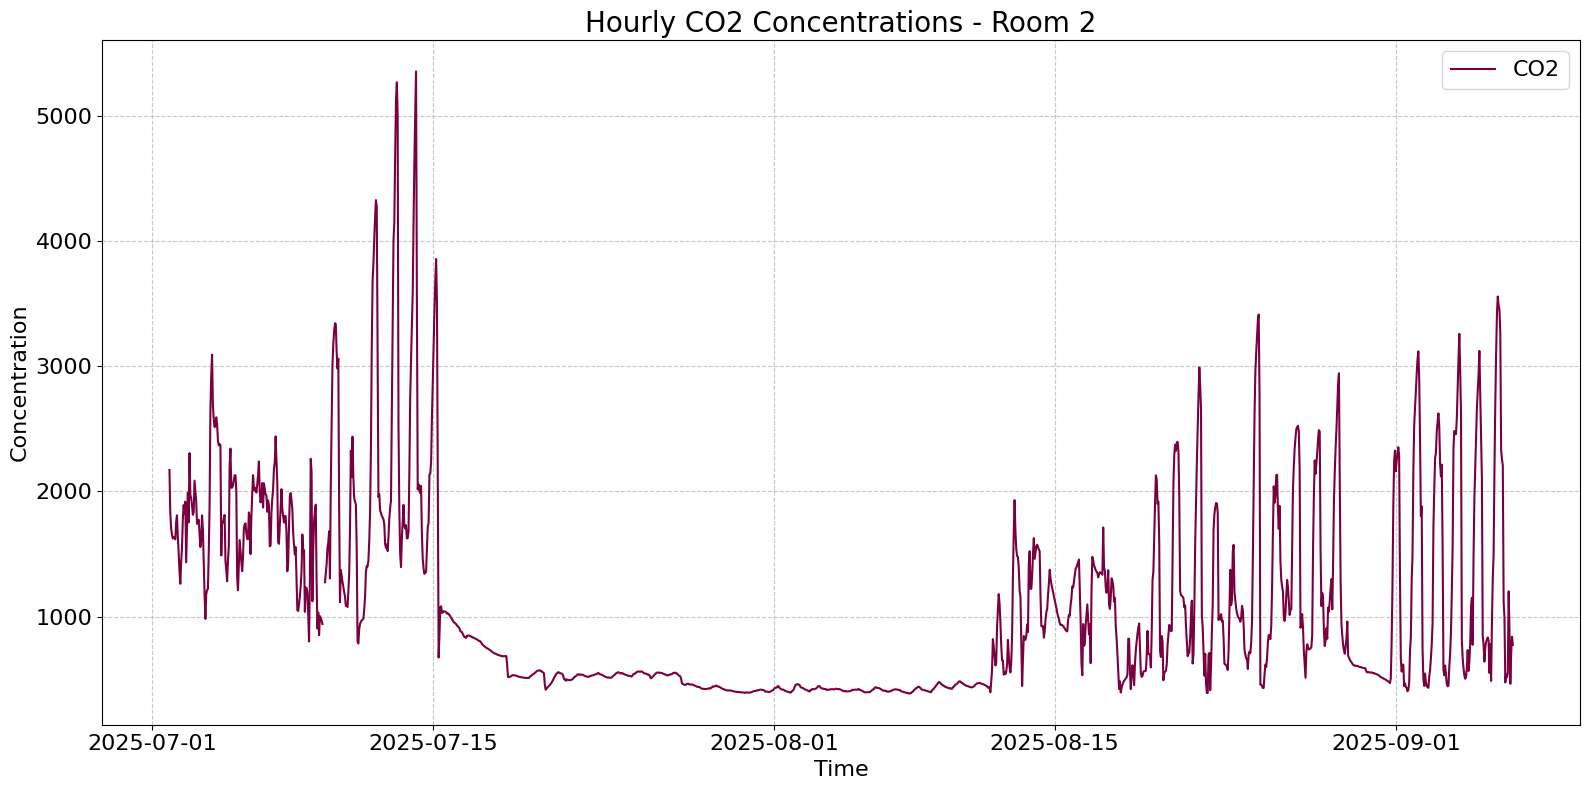

In [ ]:
df_room2 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')
df_room2['TIME'] = pd.to_datetime(df_room2['TIME'])

plt.figure(figsize=(16, 8))
if 'CO2' in df_room2.columns:
    plt.plot(df_room2['TIME'], df_room2['CO2'], label='CO2', color='#7A003F')

plt.title('Hourly CO2 Concentrations - Room 2', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Concentration', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Particulate Matter

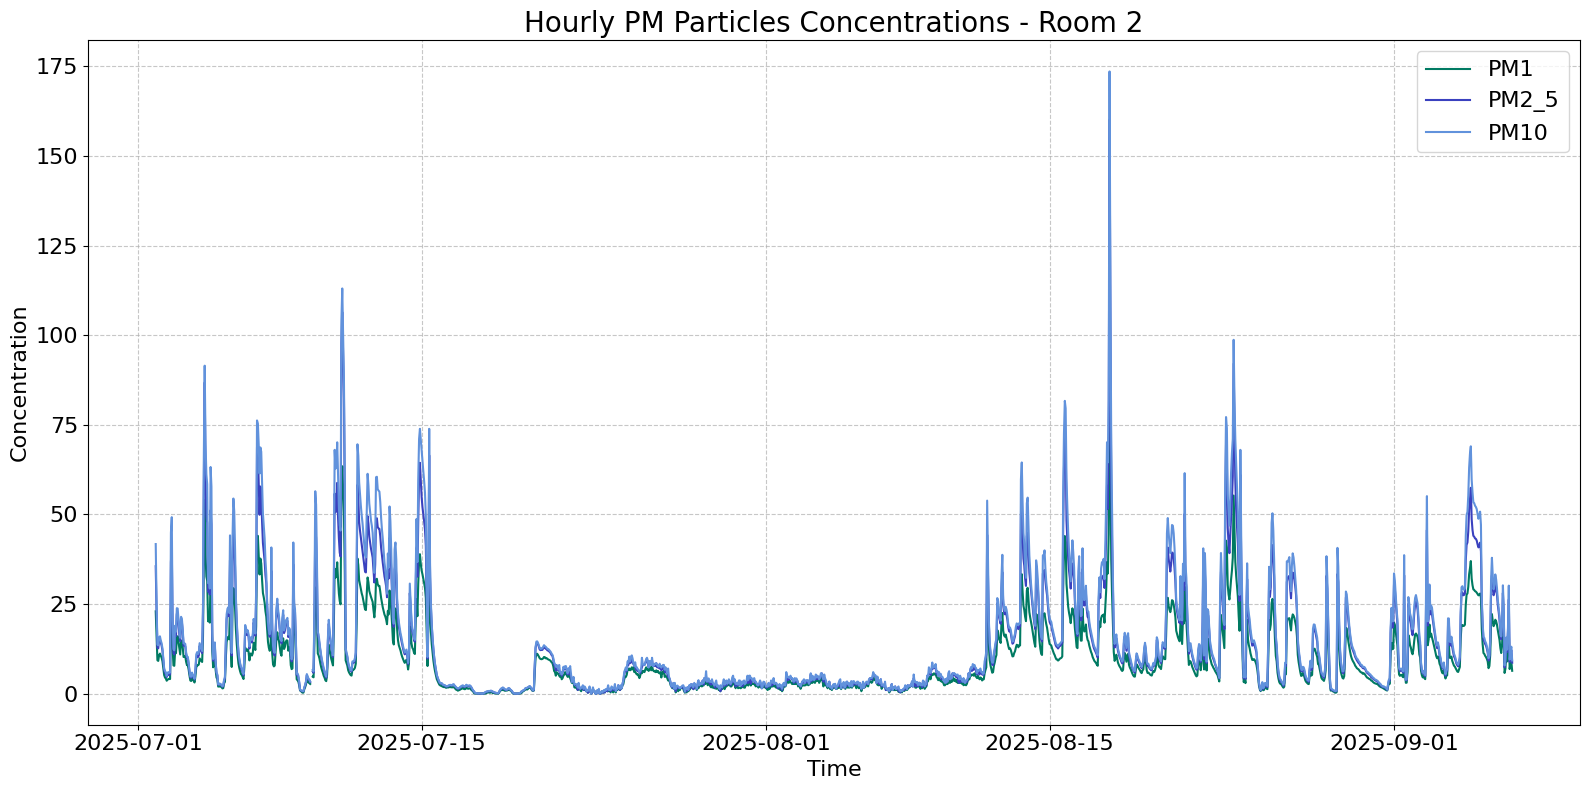

In [ ]:
df_room2 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')
df_room2['TIME'] = pd.to_datetime(df_room2['TIME'])

pm_colors = {'PM1': '#007A62', 'PM2_5': '#3A41BF', 'PM10': '#6192DC'}
plot_cols = ['PM1', 'PM2_5', 'PM10']

plt.figure(figsize=(16, 8))
for col in plot_cols:
    if col in df_room2.columns:
        plt.plot(df_room2['TIME'], df_room2[col], label=col, color=pm_colors[col])

plt.title('Hourly PM Particles Concentrations - Room 2', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Concentration', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Combined values on 2 seperate scales

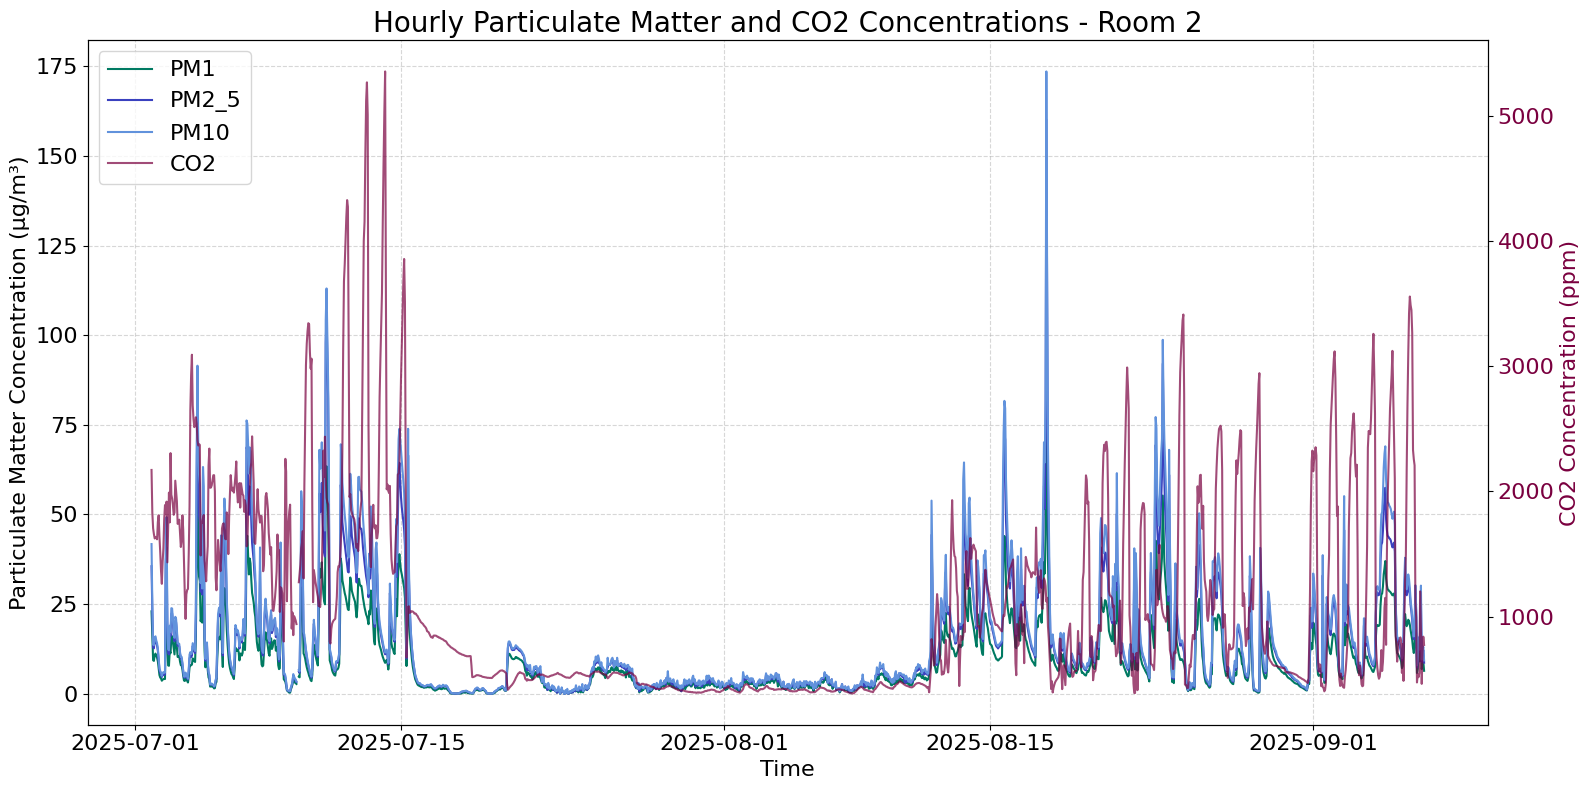

--------------------------------------------------
Period of Inactivity: 2025-07-21 23:00 to 2025-08-11 21:00
--------------------------------------------------


In [ ]:
df_room2 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')
df_room2['TIME'] = pd.to_datetime(df_room2['TIME'])

df_room2_qc = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly_qc.csv')
df_room2_qc['TIME'] = pd.to_datetime(df_room2_qc['TIME']).dt.floor('h')

valid_cols = [col for col in df_room2_qc.columns if col.endswith('_n_valid') and ('PM' in col or 'CO2' in col)]
is_perfect = (df_room2_qc[valid_cols] == 1.0).all(axis=1)
blocks = (is_perfect != is_perfect.shift()).cumsum()
valid_blocks = blocks[is_perfect]

inactivity_text = "Period of Inactivity: Not detected"
if not valid_blocks.empty:
    longest_block_id = valid_blocks.value_counts().idxmax()
    perfect_times = df_room2_qc.loc[valid_blocks[valid_blocks == longest_block_id].index, 'TIME']
    start_dt = perfect_times.min()
    end_dt = perfect_times.max()
    inactivity_text = f"Period of Inactivity: {start_dt.strftime('%Y-%m-%d %H:%M')} to {end_dt.strftime('%Y-%m-%d %H:%M')}"

fig, ax1 = plt.subplots(figsize=(16, 8))

pm_colors = {'PM1': '#007A62', 'PM2_5': '#3A41BF', 'PM10': '#6192DC'}
pm_cols = ['PM1', 'PM2_5', 'PM10']

for col in pm_cols:
    if col in df_room2.columns:
        ax1.plot(df_room2['TIME'], df_room2[col], label=col, color=pm_colors[col])

ax1.set_xlabel('Time', fontsize=16)
ax1.set_ylabel('Particulate Matter Concentration (µg/m³)', color='black', fontsize=16)
ax1.tick_params(axis='y', labelcolor='black', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
if 'CO2' in df_room2.columns:
    ax2.plot(df_room2['TIME'], df_room2['CO2'], label='CO2', color='#7A003F', alpha=0.7)
ax2.set_ylabel('CO2 Concentration (ppm)', color='#7A003F', fontsize=16)
ax2.tick_params(axis='y', labelcolor='#7A003F', labelsize=16)

plt.title('Hourly Particulate Matter and CO2 Concentrations - Room 2', fontsize=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=16)

fig.tight_layout()
plt.show()

print("-" * 50)
print(inactivity_text)
print("-" * 50)

## Outdoor

CO2

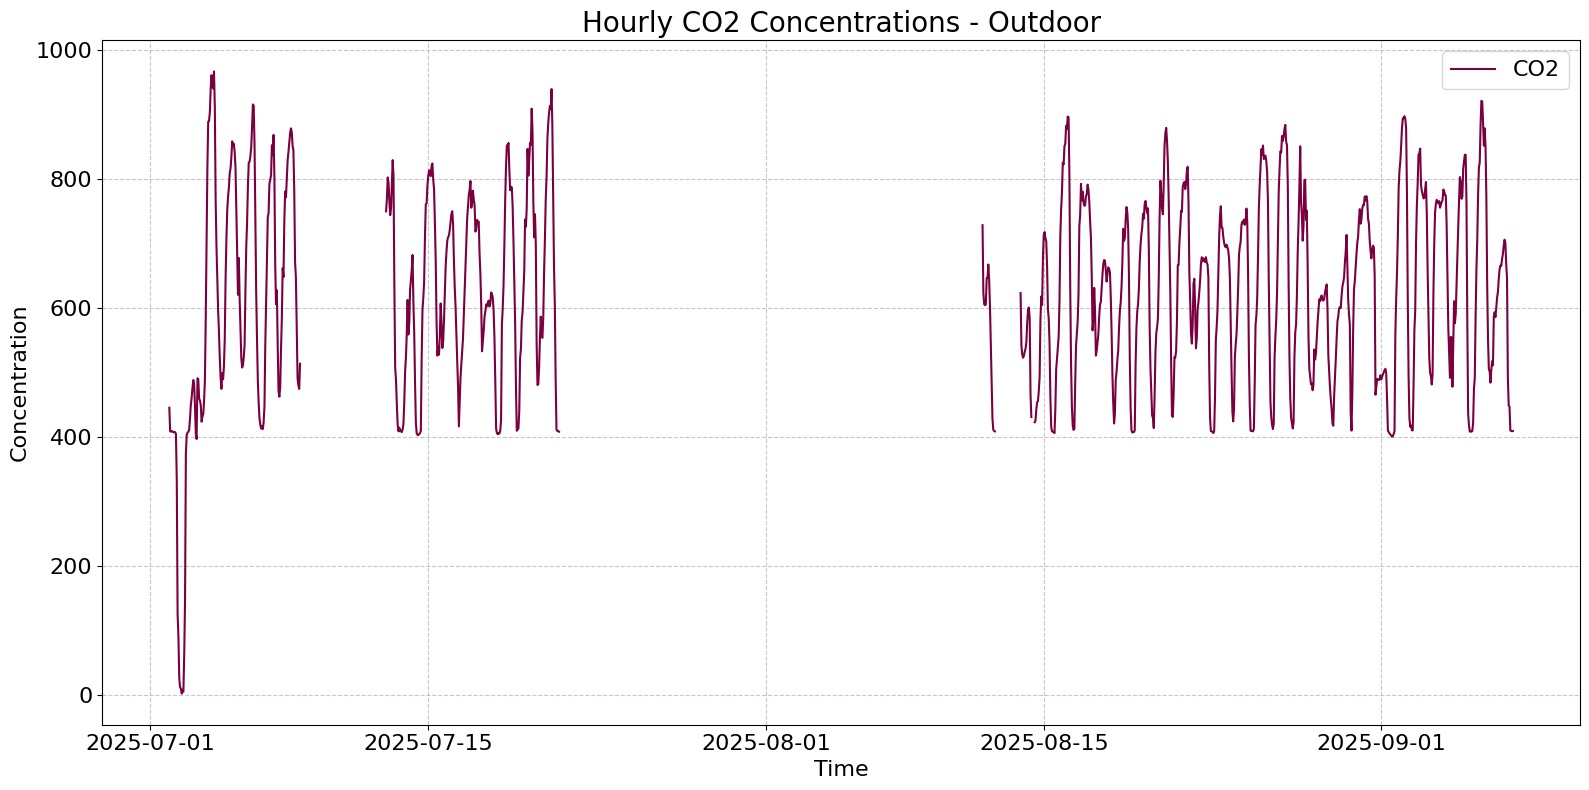

In [ ]:
df_outdoor = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/outdoor_hourly.csv')
df_outdoor['TIME'] = pd.to_datetime(df_outdoor['TIME'])

plt.figure(figsize=(16, 8))
if 'CO2' in df_outdoor.columns:
    plt.plot(df_outdoor['TIME'], df_outdoor['CO2'], label='CO2', color='#7A003F')

plt.title('Hourly CO2 Concentrations - Outdoor', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Concentration', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Particulate Matter

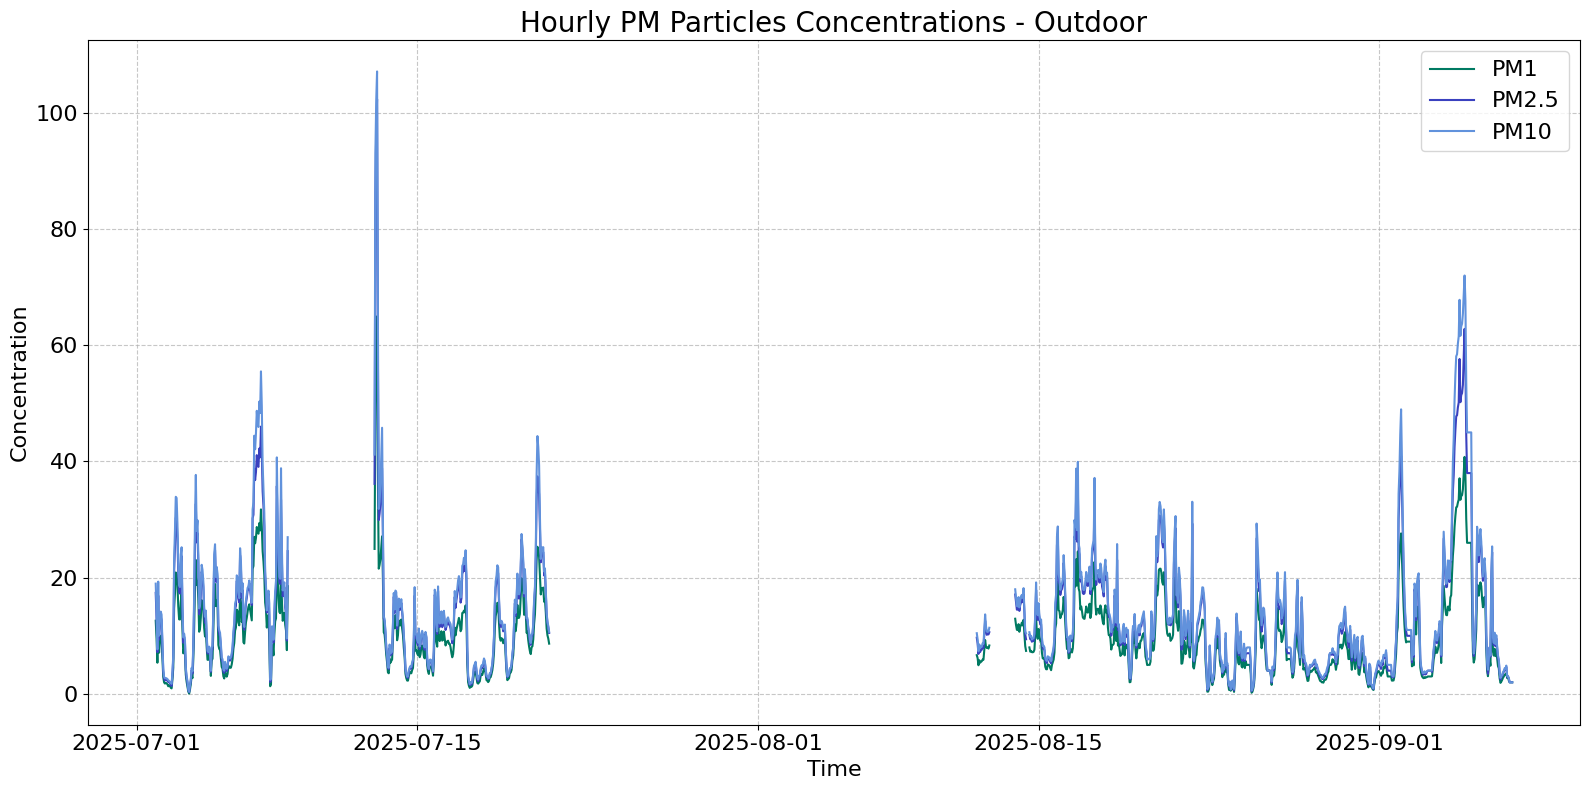

In [ ]:
df_outdoor = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/outdoor_hourly.csv')
df_outdoor['TIME'] = pd.to_datetime(df_outdoor['TIME'])

pm_colors = {'PM1': '#007A62', 'PM2.5': '#3A41BF', 'PM10': '#6192DC'}
plot_cols = ['PM1', 'PM2.5', 'PM10']

plt.figure(figsize=(16, 8))
for col in plot_cols:
    if col in df_outdoor.columns:
        plt.plot(df_outdoor['TIME'], df_outdoor[col], label=col, color=pm_colors[col])

plt.title('Hourly PM Particles Concentrations - Outdoor', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Concentration', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Combined values on 2 seperate scales

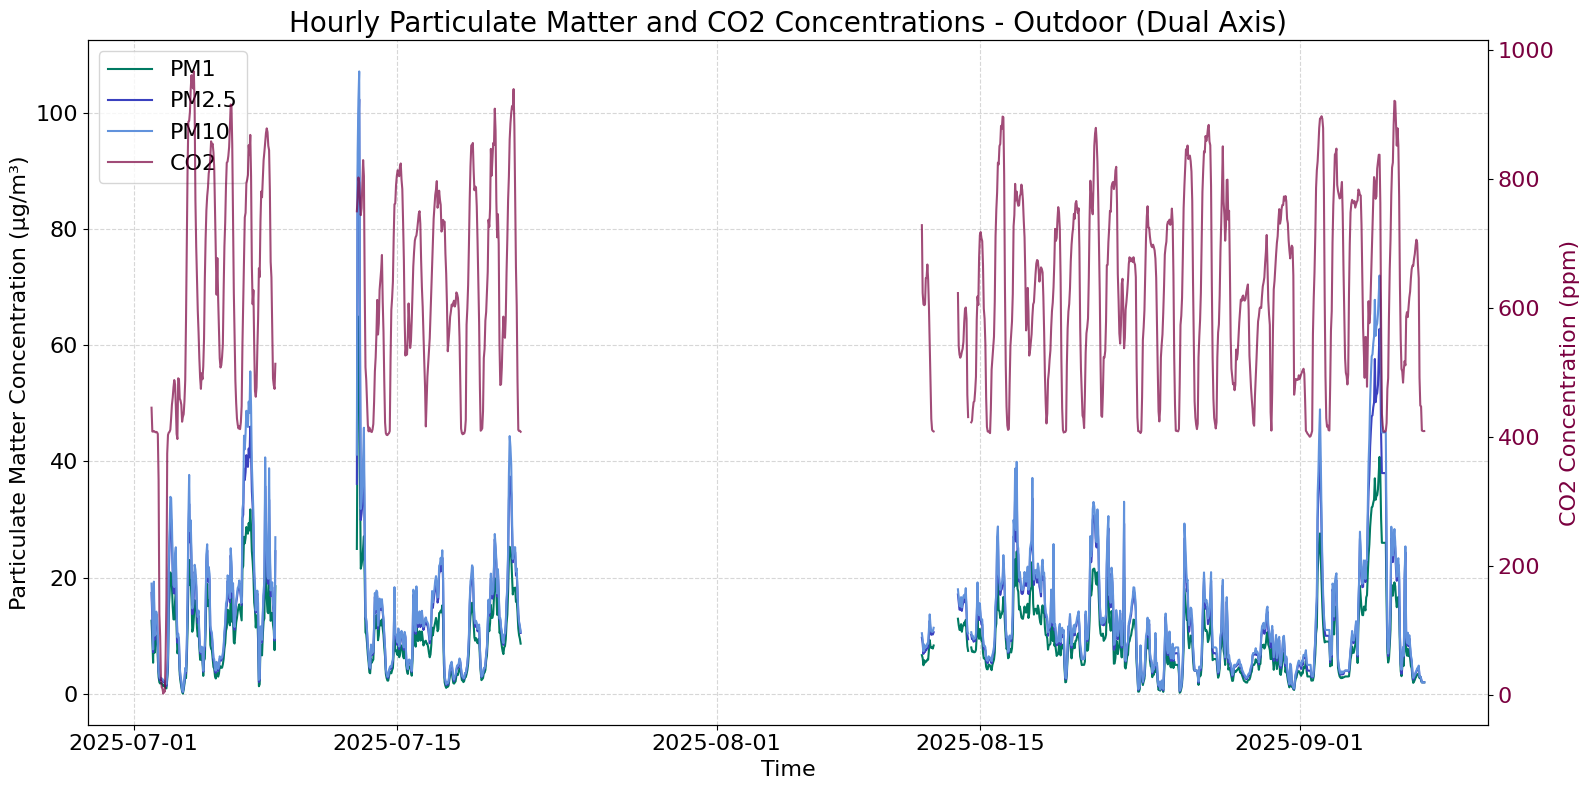

In [ ]:
df_outdoor = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/outdoor_hourly.csv')
df_outdoor['TIME'] = pd.to_datetime(df_outdoor['TIME'])

fig, ax1 = plt.subplots(figsize=(16, 8))

pm_colors = {'PM1': '#007A62', 'PM2.5': '#3A41BF', 'PM10': '#6192DC'}
pm_cols = ['PM1', 'PM2.5', 'PM10']

for col in pm_cols:
    if col in df_outdoor.columns:
        ax1.plot(df_outdoor['TIME'], df_outdoor[col], label=col, color=pm_colors[col])

ax1.set_xlabel('Time', fontsize=16)
ax1.set_ylabel('Particulate Matter Concentration (µg/m³)', color='black', fontsize=16)
ax1.tick_params(axis='y', labelcolor='black', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
if 'CO2' in df_outdoor.columns:
    ax2.plot(df_outdoor['TIME'], df_outdoor['CO2'], label='CO2', color='#7A003F', alpha=0.7)
ax2.set_ylabel('CO2 Concentration (ppm)', color='#7A003F', fontsize=16)
ax2.tick_params(axis='y', labelcolor='#7A003F', labelsize=16)

plt.title('Hourly Particulate Matter and CO2 Concentrations - Outdoor (Dual Axis)', fontsize=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=16)

fig.tight_layout()
plt.show()

# Stari notes

Underfitting?

Probati Spearman Rank Correlation
Canonical correlation Analysis CCA

p-value = confidence?

brinemo sto su nam korelacije slabe

kada nema ljudi korelacija je 0.39
kada ima ljudi korelacija je 0.14

ovo se desava zato sto ljudi proizvode co2 i povecavaju koncentraciju u vazduhu ali ne stvaraju nuzno i toliko vise PM cestica, one se najvise skupljaju pri vecim aktivnostima i "dizanju prasine"

shodno tome cak i nije lose sto imamo slabije korelacije jer smo na osnovu njih zakljucili tu vezu u odnosu polutanata i ljudskog prisustva

ovo nam je omoguceno prvobitnom analizom kretanja vrednosti koja prikazuje velike razlike tokom perioda odsustva i boravka ljudi, kojima mozemo da odvojimo vreme i uradimo korelacionu matricu na osnovu odvojenih delova baze i dalje uporedimo vrednosti kao gore u tekstu

These findings suggest taht human presence acts as a noise generator that decouples the relationship between CO2 and PM

Active Occupant hypothesis

PM change is stochastic while CO2 is constant

U sustini shvatili smo da nisu isti uzroci podizanja nivoa koncentracija PM i CO2 cestica u vazduhu
CO2 se pod ljudskim prisustvom dize konstantno zbog disanja dok se PM cestice podizu kada ima puno kretanja "dizanja prasine". S druge strane, faktori koji uticu na posmatrane cestice bez boravka ljudi su stalni poput ventilacije, uticaja same zgrade...


# Particle Correlations

## Room 1

Korelaciona Matrica hourly

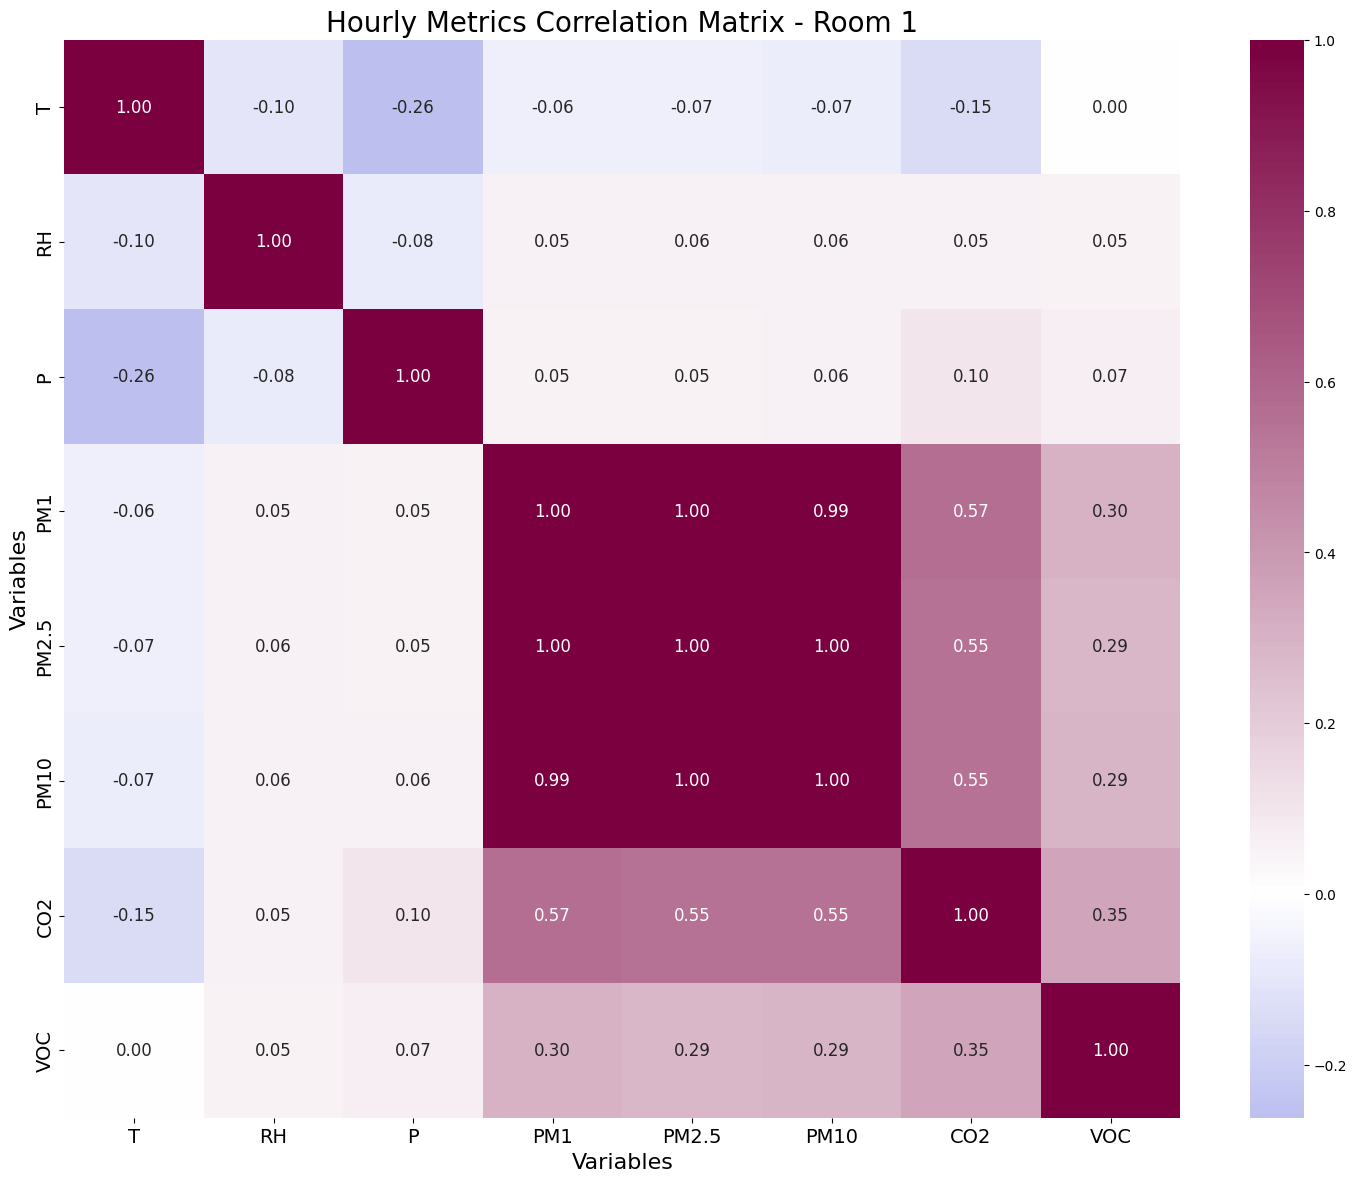

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

hourly_cols = [c for c in df_room1.columns if c != 'TIME']
corr = df_room1[hourly_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap=custom_cmap, annot=True, fmt=".2f", center=0, annot_kws={"size": 12})
plt.title('Hourly Metrics Correlation Matrix - Room 1', fontsize=20)
plt.xlabel('Variables', fontsize=16)
plt.ylabel('Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

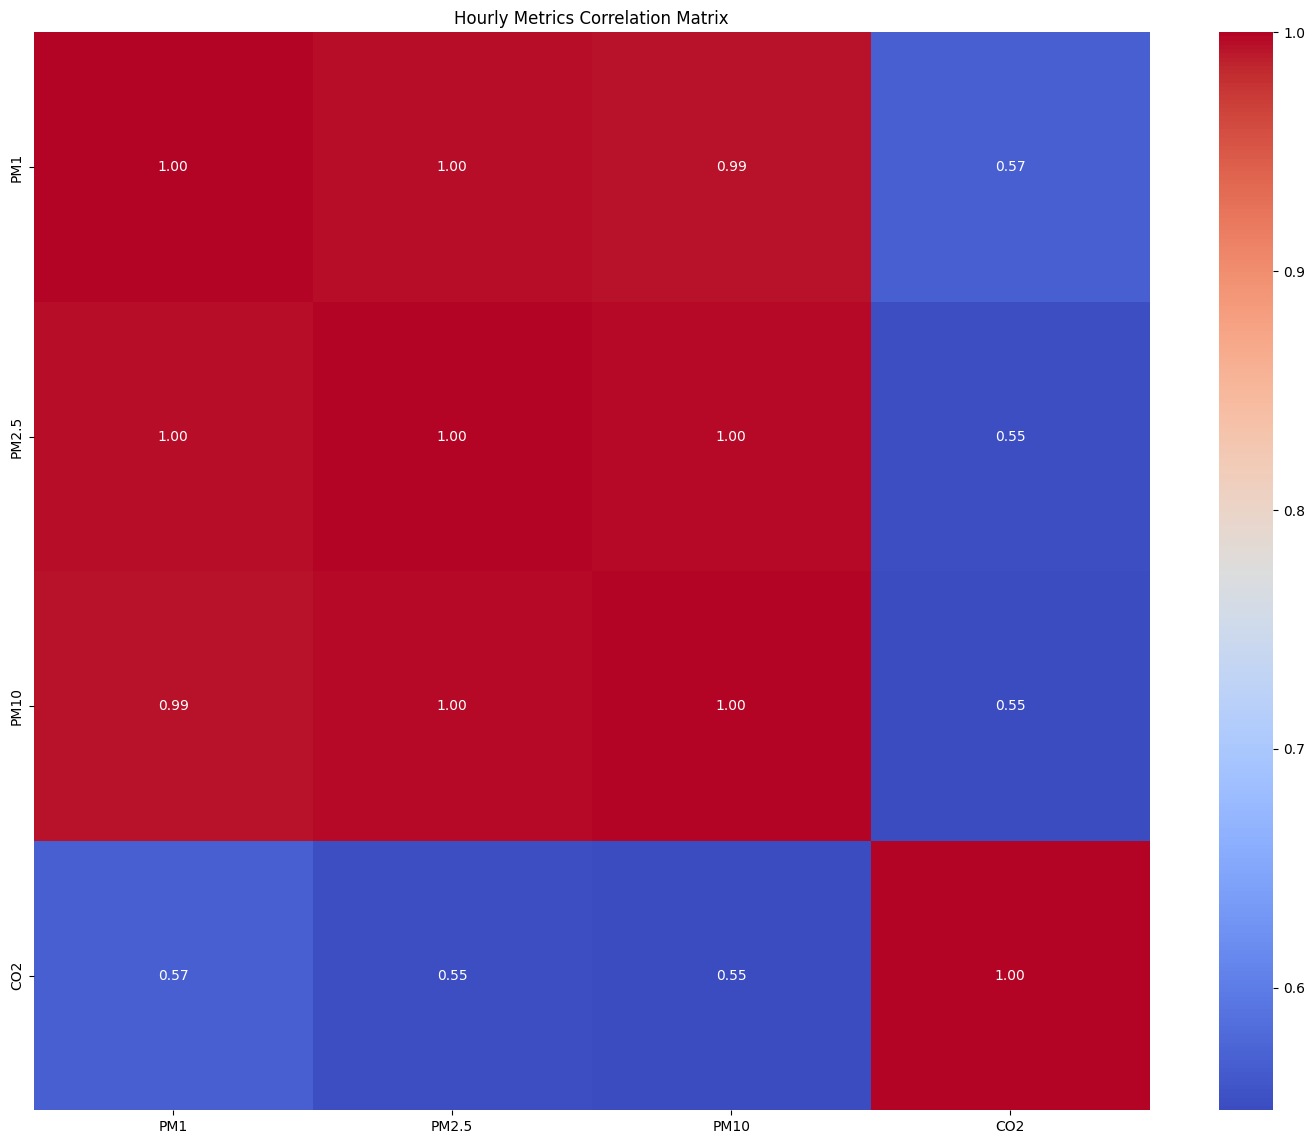

In [ ]:
hourly_cols = [c for c in df_room1.columns if c not in ['TIME', 'RH', 'P', 'T', 'VOC']]

corr = df_room1[hourly_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Hourly Metrics Correlation Matrix')
plt.show()

## Room 2

Human activity period
 - start_date = '2025-08-15'
 - end_date = '2025-09-01'

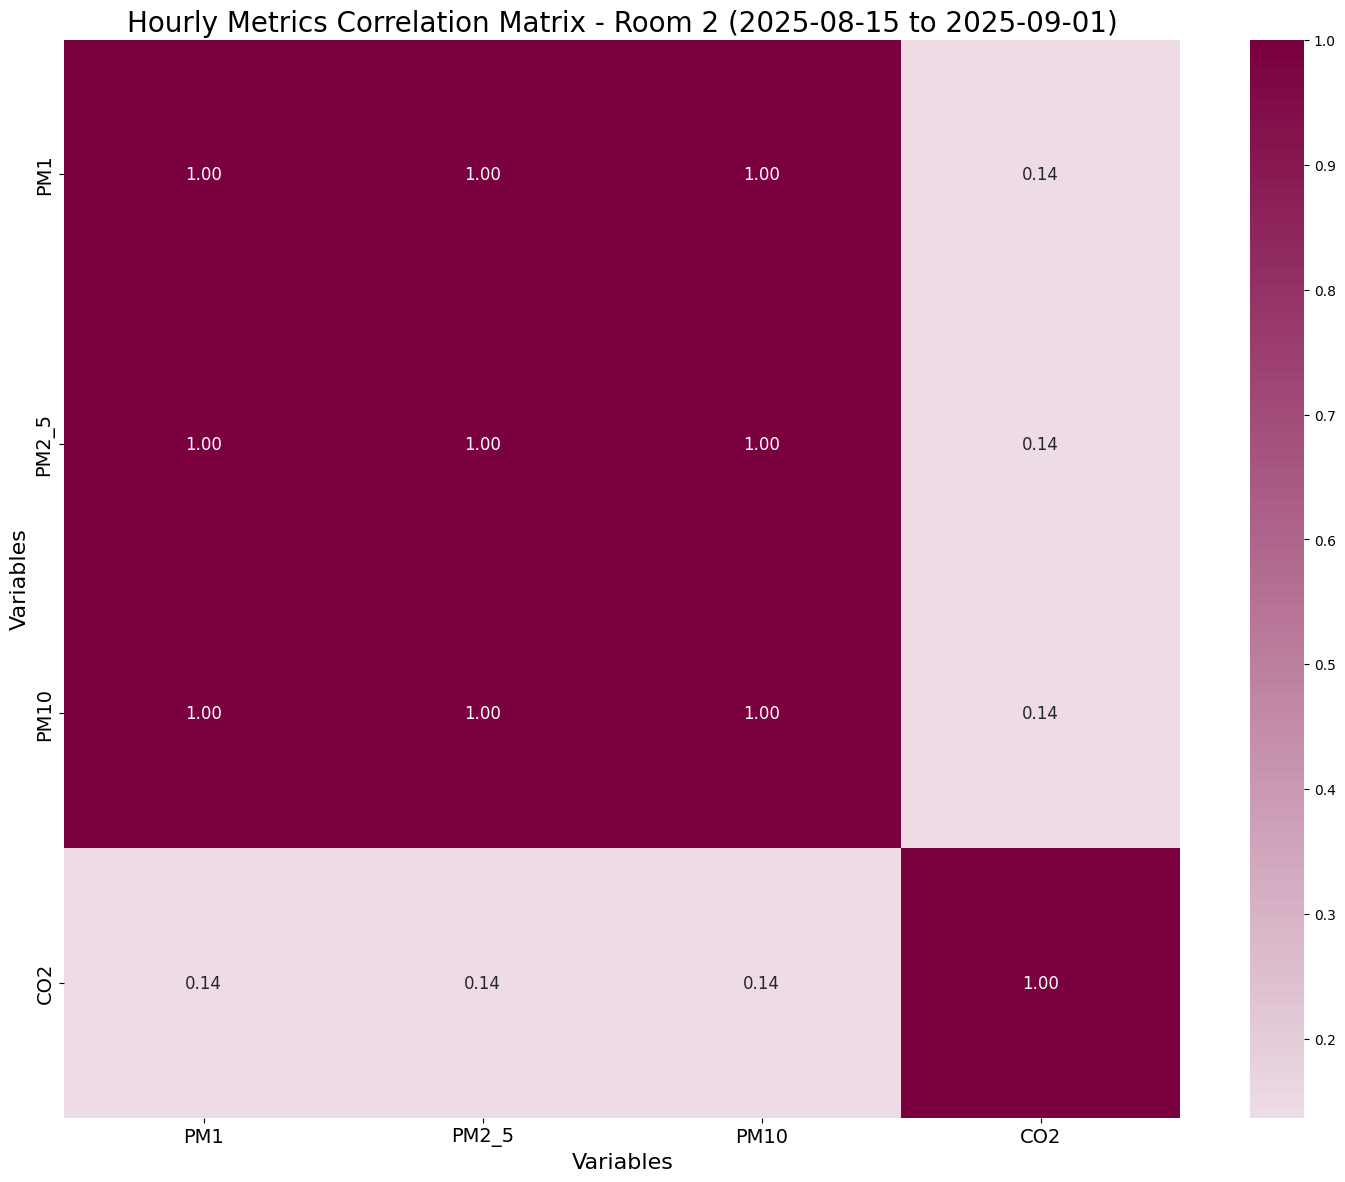

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

start_date = '2025-08-15'
end_date = '2025-09-01'

df2_filtered = df_room2[(df_room2['TIME'] >= start_date) & (df_room2['TIME'] <= end_date)].copy()
hourly_cols = [c for c in df2_filtered.columns if c not in ['TIME', 'RH', 'P', 'T', 'VOC']]
corr = df2_filtered[hourly_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap=custom_cmap, annot=True, fmt=".2f", center=0, annot_kws={"size": 12})
plt.title(f'Hourly Metrics Correlation Matrix - Room 2 ({start_date} to {end_date})', fontsize=20)
plt.xlabel('Variables', fontsize=16)
plt.ylabel('Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Inactivity period
  - start_date = '2025-07-22'
  - end_date = '2025-08-10'

entalpija - vlaga i temperatura - korelacija co2 i entalpije
dinamicki se razlikuju prostiranjem u vremenu, nema korelacije

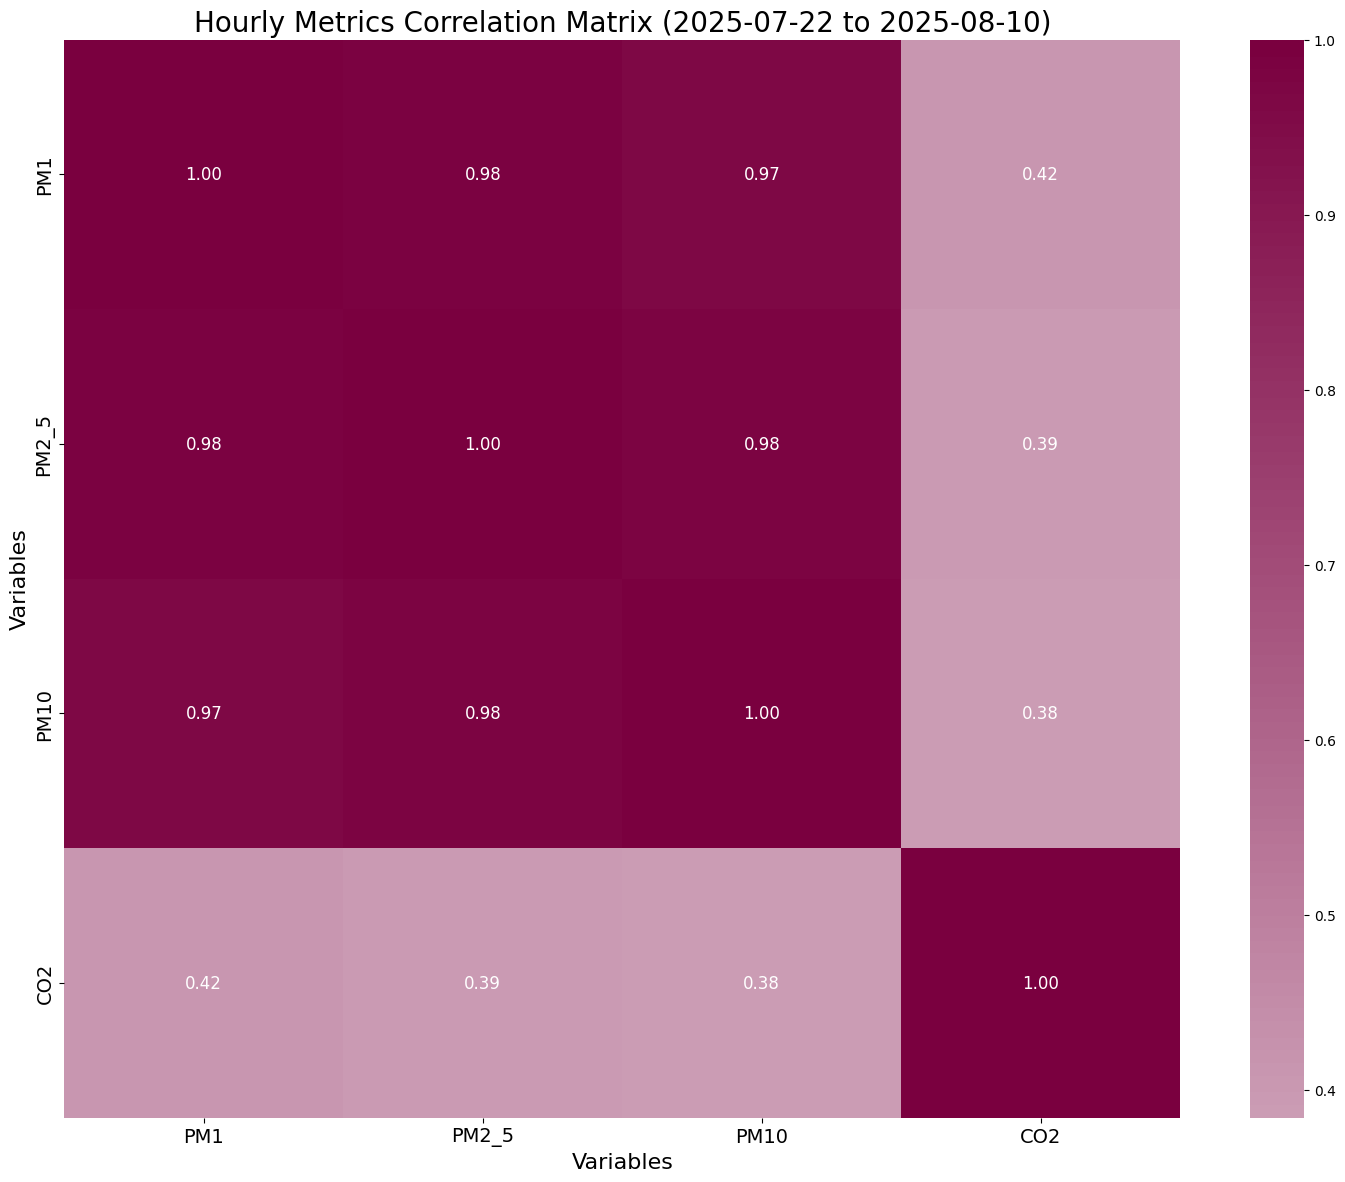

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

start_date = '2025-07-22'
end_date = '2025-08-10'

df2_filtered = df_room2[(df_room2['TIME'] >= start_date) & (df_room2['TIME'] <= end_date)].copy()
hourly_cols = [c for c in df2_filtered.columns if c not in ['TIME', 'RH', 'P', 'T', 'VOC']]
corr = df2_filtered[hourly_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap=custom_cmap, annot=True, fmt=".2f", center=0, annot_kws={"size": 12})
plt.title(f'Hourly Metrics Correlation Matrix ({start_date} to {end_date})', fontsize=20)
plt.xlabel('Variables', fontsize=16)
plt.ylabel('Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Srediti dalje dole v

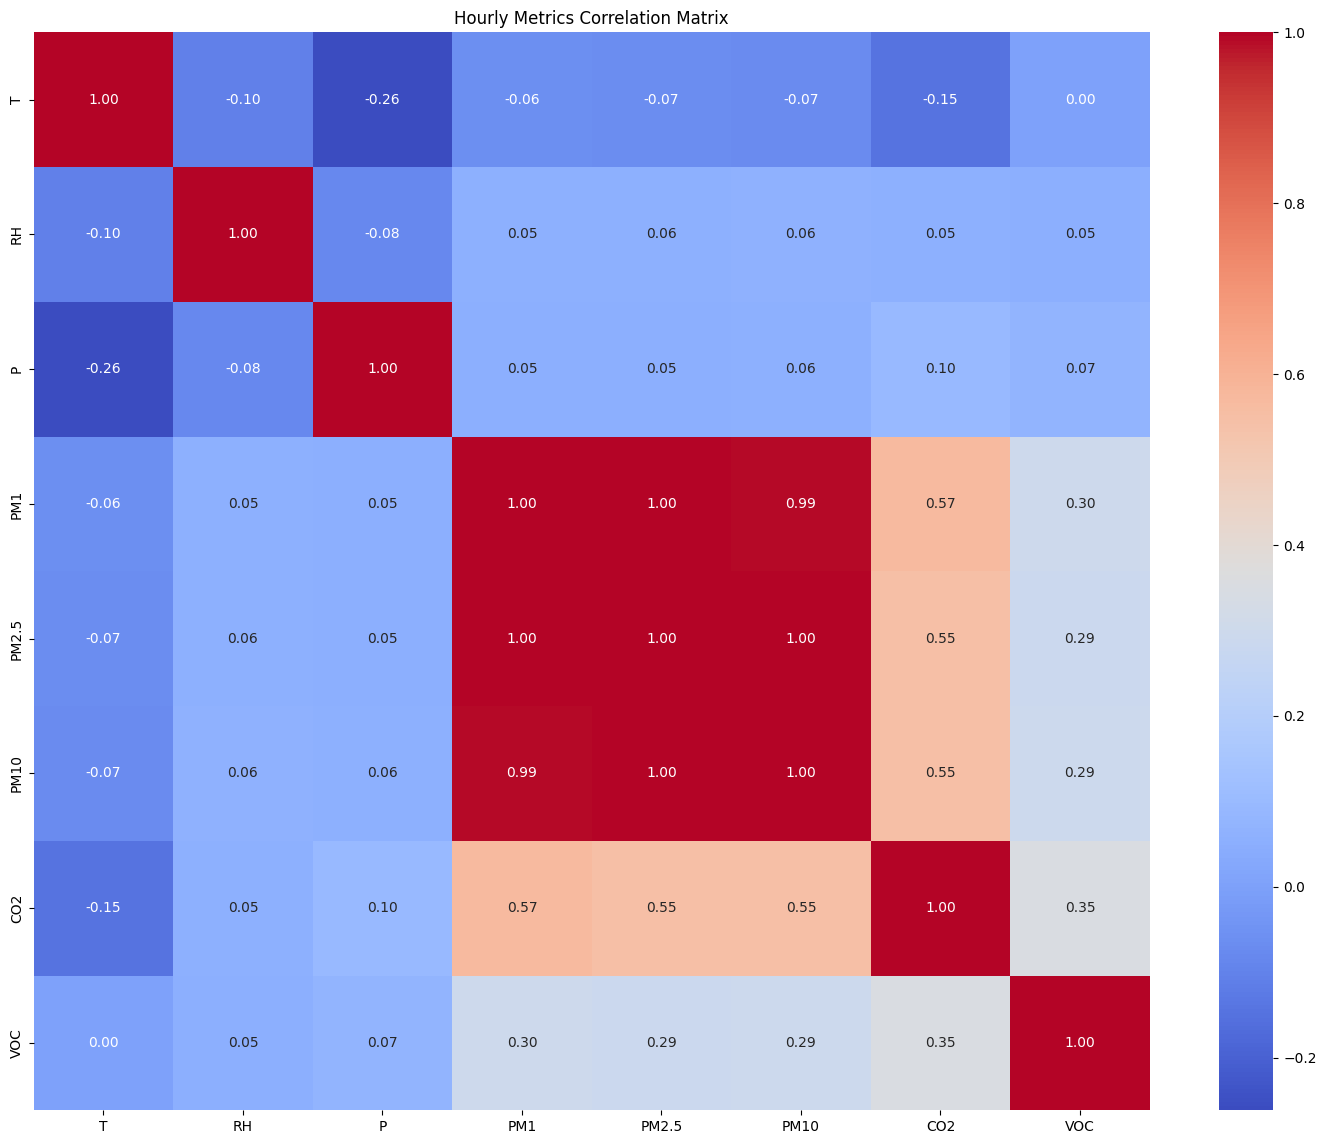

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')

df1['TIME'] = pd.to_datetime(df1['TIME'])

hourly_cols = [c for c in df1.columns if c != 'TIME']

corr = df1[hourly_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Hourly Metrics Correlation Matrix')
plt.show()

KOrelaciona matrica za room2_hourly
 - start_date = '2025-08-15'
 - end_date = '2025-09-01'

 - (period sa najvise spajkova)
 - ukazuje na ljudsku aktivnost

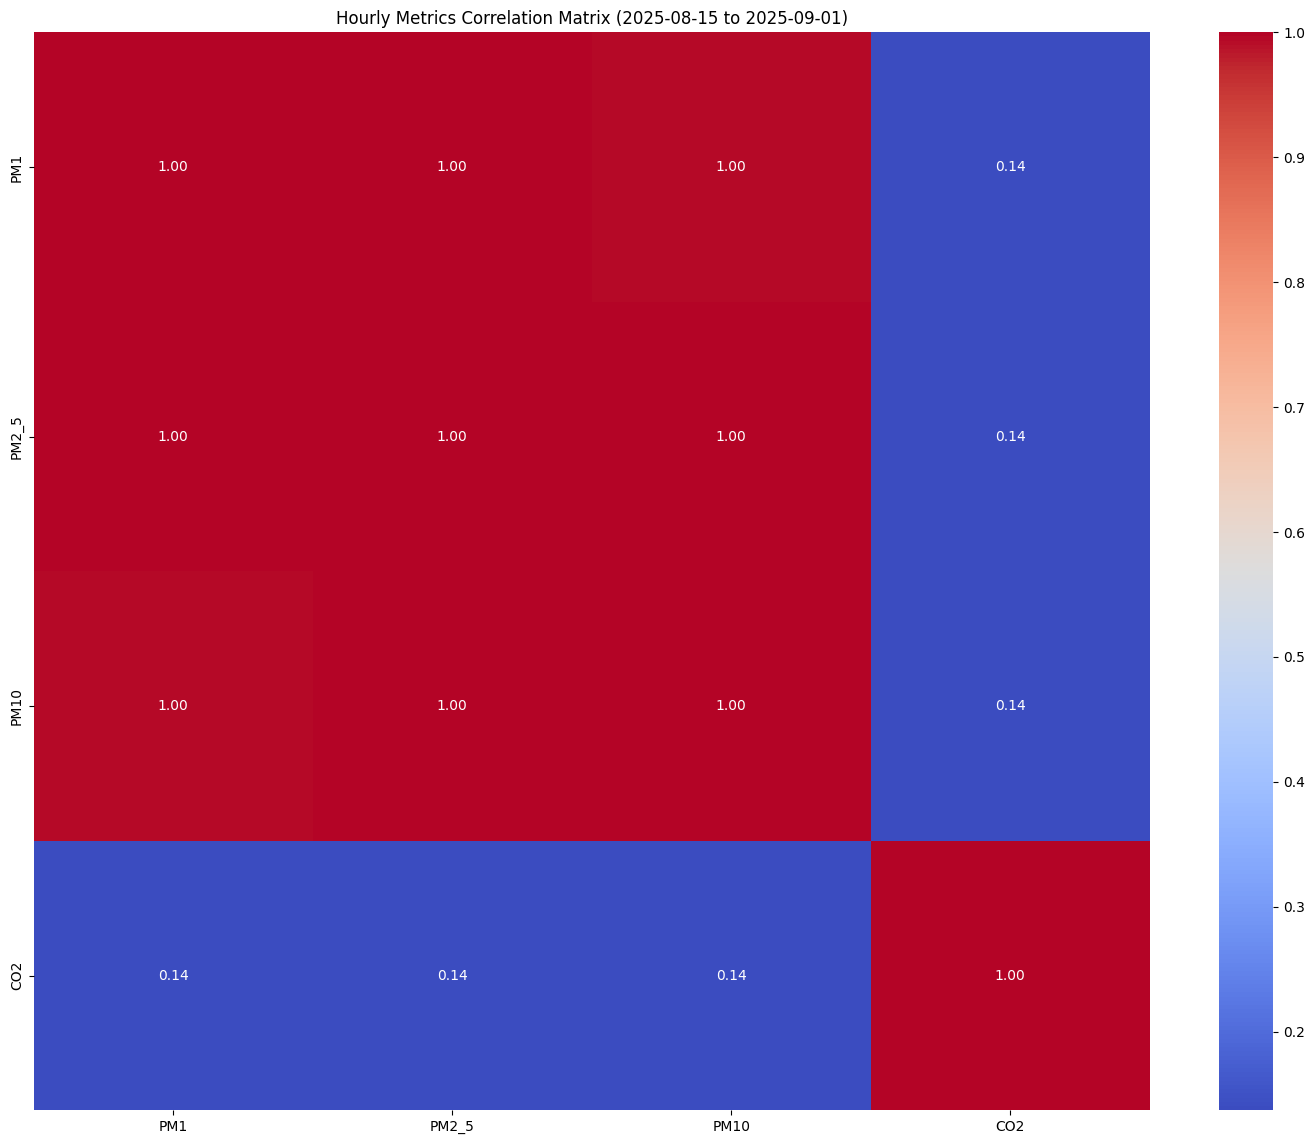

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

df2['TIME'] = pd.to_datetime(df2['TIME'])

start_date = '2025-08-15'
end_date = '2025-09-01'

df2_filtered = df2[(df2['TIME'] >= start_date) & (df2['TIME'] <= end_date)].copy()

hourly_cols = [c for c in df2_filtered.columns if c not in ['TIME', 'RH', 'P', 'T', 'VOC']]

corr = df2_filtered[hourly_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title(f'Hourly Metrics Correlation Matrix ({start_date} to {end_date})')
plt.show()

## kljucno nam je da gledamo period dnevne aktivnosti, drasticne promene od skoro nikakve korelacije do skoro potpuno, probati spearmana

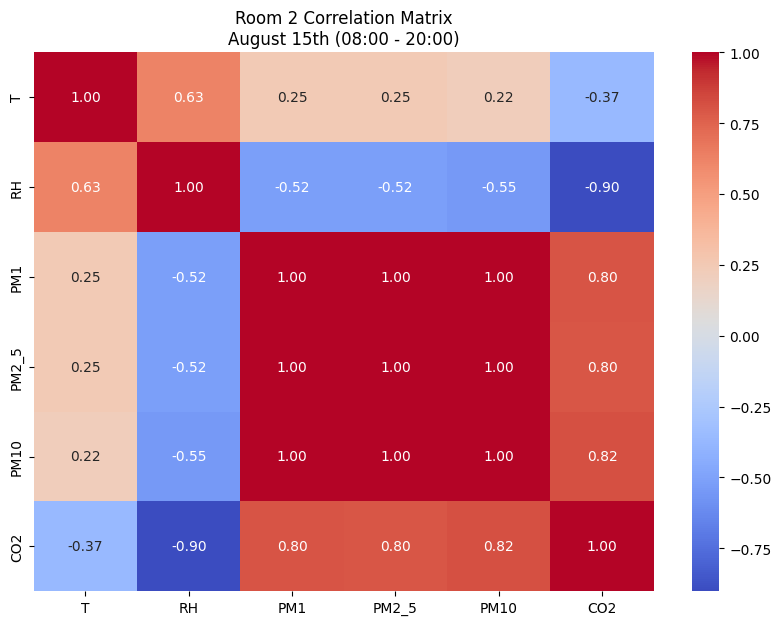

In [ ]:
start_time = '2025-08-15 08:00:00'
end_time = '2025-08-15 20:00:00'

df2_filtered = df2[(df2['TIME'] >= start_time) & (df2['TIME'] <= end_time)].copy()

hourly_cols = [c for c in df2_filtered.columns if c not in ['TIME', 'P', 'VOC']]

corr = df2_filtered[hourly_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Room 2 Correlation Matrix\nAugust 15th (08:00 - 20:00)')
plt.show()

Spearmanova korelacija

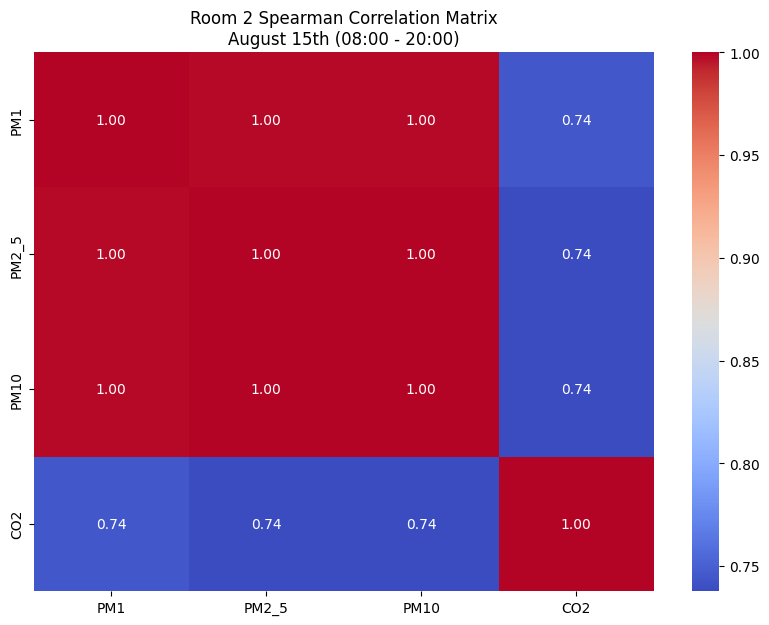

In [ ]:
df2['TIME'] = pd.to_datetime(df2['TIME'])

start_time = '2025-08-15'
end_time = '2025-08-16'

df2_filtered = df2[(df2['TIME'] >= start_time) & (df2['TIME'] <= end_time)].copy()

hourly_cols = [c for c in df2_filtered.columns if c not in ['TIME', 'RH', 'P', 'T', 'VOC']]

corr = df2_filtered[hourly_cols].corr(method='spearman')

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Room 2 Spearman Correlation Matrix\nAugust 15th (08:00 - 20:00)')
plt.show()

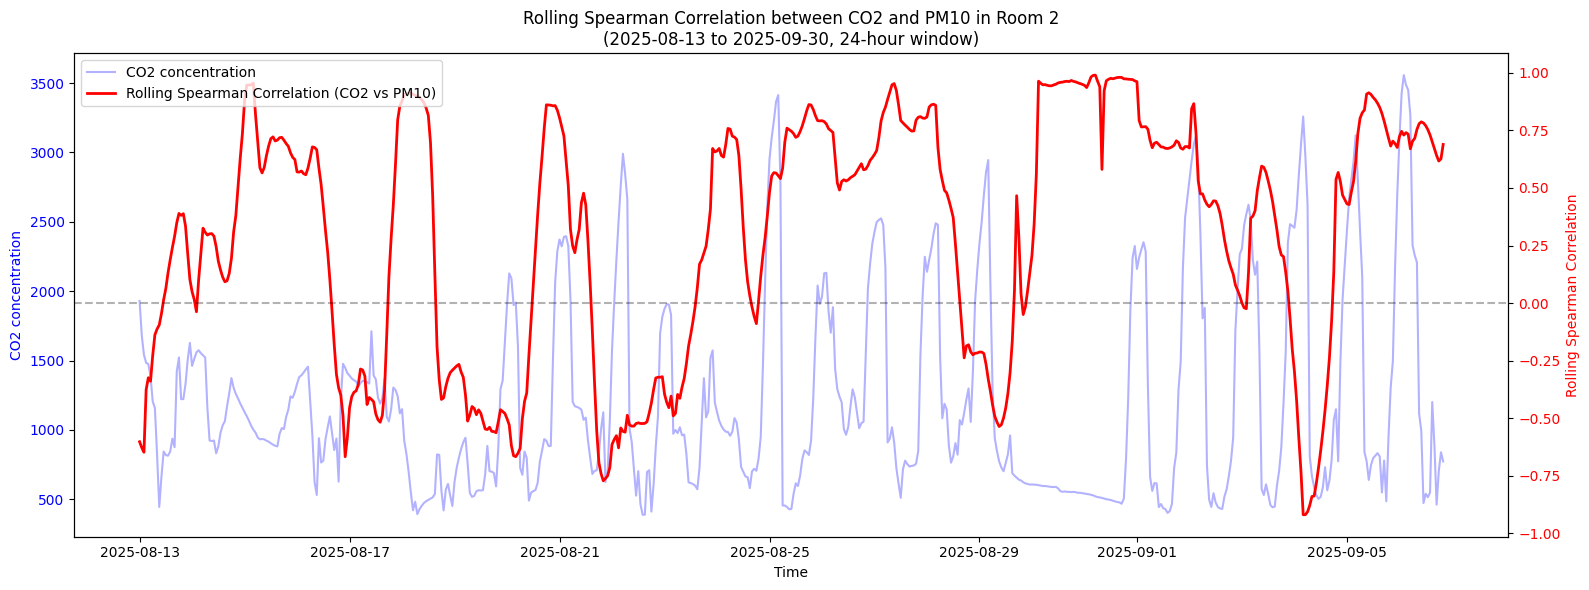

In [ ]:
start_time = '2025-08-13'
end_time = '2025-09-30'

df2_filtered = df2[(df2['TIME'] >= start_time) & (df2['TIME'] <= end_time)].copy()

df2_filtered_numeric = df2_filtered[['TIME', 'CO2', 'PM10']].dropna()

if not df2_filtered_numeric.empty:
    df2_filtered_numeric['CO2_rank'] = df2_filtered_numeric['CO2'].rank(method='average')
    df2_filtered_numeric['PM10_rank'] = df2_filtered_numeric['PM10'].rank(method='average')

    window_size = 24
    df2_filtered_numeric['rolling_corr'] = df2_filtered_numeric['CO2_rank'].rolling(
        window=window_size, min_periods=1, center=True
    ).corr(df2_filtered_numeric['PM10_rank'])

    fig, ax1 = plt.subplots(figsize=(16, 6))

    ax1.plot(df2_filtered_numeric['TIME'], df2_filtered_numeric['CO2'], color='blue', alpha=0.3, label='CO2 concentration')
    ax1.set_ylabel('CO2 concentration', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()
    ax2.plot(df2_filtered_numeric['TIME'], df2_filtered_numeric['rolling_corr'], color='red', linewidth=2, label='Rolling Spearman Correlation (CO2 vs PM10)')
    ax2.axhline(0, color='black', linestyle='--', alpha=0.3) # Zero line
    ax2.set_ylabel('Rolling Spearman Correlation', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(f'Rolling Spearman Correlation between CO2 and PM10 in Room 2\n({start_time} to {end_time}, {window_size}-hour window)')
    ax1.set_xlabel('Time')
    plt.xticks(rotation=45, ha='right')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough data to calculate rolling correlation for the period {start_time} to {end_time} or variables CO2/PM10.")

Kendalova korelacija


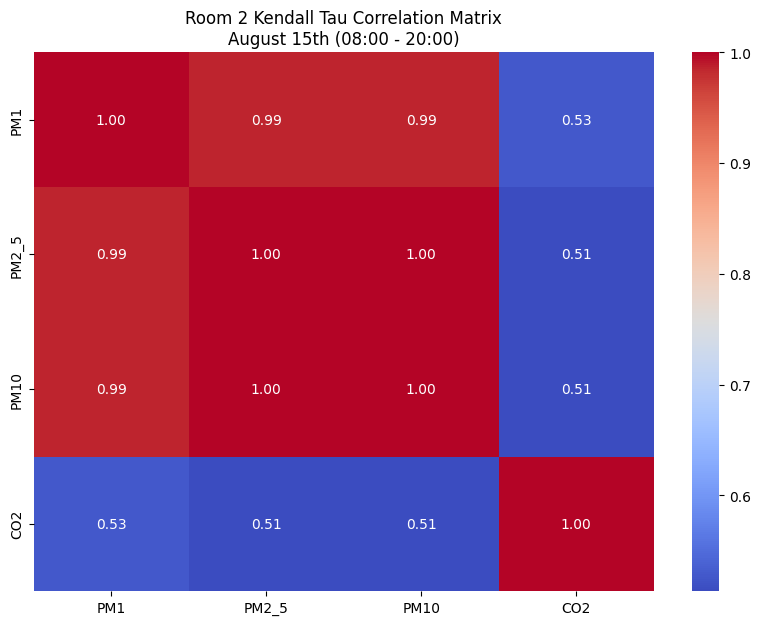

In [ ]:
start_time = '2025-08-15'
end_time = '2025-08-16'

df2_filtered = df2[(df2['TIME'] >= start_time) & (df2['TIME'] <= end_time)].copy()

hourly_cols = [c for c in df2_filtered.columns if c not in ['TIME', 'RH', 'P', 'T', 'VOC']]

corr = df2_filtered[hourly_cols].corr(method='kendall')

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Room 2 Kendall Tau Correlation Matrix\nAugust 15th (08:00 - 20:00)')
plt.show()

# Zakljucak za korelacione matrice
  * Primecena je razlika u nivou korelacije izmedju CO2 i PM cestica u razlicitim vremenskim periodima (kada ima ljudi i kada nema ljudi u prostoriji)
  * Kada ima ljudi korelacija CO2 je priblizno 0.14 za sve PM cestice a kada nema ljudi korelacija je priblizno 0.39 sto ukazuje na to da korelacija raste kada ljudi nisu prisutni zbog toga sto su svi spoljni faktori uskladjeni a pada kada su prisutni zbog toga sto disanje nije uskladjeno sa podizanjem prasine u prostoriji Tj. postoji mogucnost da je CO2 tj. disanje bilo prisutno a podizanje prasine nije u vecim periodima.  

 Predlozi
 - In scientific research, a low correlation (like 0.14) isn't necessarily "bad"—it is often a finding in itself. It suggests that in that specific room, CO2 and PM10 are coming from different sources or are being affected by different ventilation patterns.
 - To make your analysis more robust for a research paper, you should focus on explaining the variance rather than just trying to force a higher number.


 1. Identify and Segment by Sources
 - CO2 is primarily a proxy for human respiration, while PM10 often comes from physical activities (resuspension of dust) or outdoor infiltration.Activity Logs: Check if the room with 0.14 correlation had people present (high CO2) but no movement (low PM10), or vice versa (e.g., a vacuum cleaner running in an empty room).Source Apportionment: Use Principal Component Analysis (PCA) to see if CO2 and PM10 load onto different "factors." This proves scientifically that they represent different environmental processes.

 2. Account for Ventilation and Lag
 - The relationship between gases (CO2) and particles (PM10) is rarely instant or linear.Time-Lag Analysis: Use Cross-Correlation Functions (CCF) to see if PM10 follows CO2 with a delay (e.g., 15–30 minutes).Ventilation Effect: In rooms with high air exchange rates (windows open), both pollutants may be flushed out so quickly that they never "sync up," leading to the 0.14 correlation you see.

 3. Use Advanced Statistical MethodsStandard Pearson correlation assumes a linear relationship, which IAQ data often lacks.Spearman Rank Correlation: Use this if your data has outliers or is non-linear; it is often more "honest" for environmental sensors.Canonical Correlation Analysis (CCA): If you have other variables (humidity, temperature), use CCA to see how sets of meteorological factors influence the pollutants as a whole.

Upotreba pronalaska smanjivanja korelacije pri prisustvu ljudi u prostoriji

* In our dataset we found out that when people are in the room (spikes on polution graf) the correlation are lower, like 0.14 and when they are not in the room rorelation is like 0.39... What we can conclude from that?
  - This is a significant finding for an Indoor Air Quality (IAQ) paper. It suggests that human presence acts as a "noise generator" that decouples the relationship between CO2 and PM10.

  - BITNO:
  1. Different Source MechanismsOccupied (0.14 correlation):
     - When people enter, they introduce independent sources. CO2 rises steadily from breathing (metabolic rate), but PM10 spikes sporadically from "re-suspension" (kicking up dust from the floor) or specific activities like moving papers or eating. Because these two actions (breathing vs. moving) don't happen at the exact same intensity or rhythm, the correlation drops.
     - Unoccupied (0.39 correlation): When the room is empty, both pollutants are likely governed by the same physical process: the building's ventilation system (HVAC) or natural infiltration. Both pollutants decay or accumulate at a steady, shared rate based on air exchange, leading to a "cleaner" mathematical relationship.

  2. The "Active Occupant" HypothesisIn scientific terms, you can conclude that occupant-induced PM10 is stochastic (random) while occupant-induced CO2 is constant.A person breathes at a consistent rate (constant CO2 source).A person does not "shed" or "kick up" PM10 at a consistent rate (random PM10 source).This mismatch naturally breaks the correlation during occupied hours.


  3. Practical Research ConclusionYou can argue that CO2 is a poor proxy for PM10 in high-activity zones.While many researchers use CO2 to estimate general "stuffiness," your data proves that in occupied spaces, PM10 follows its own rules (activity-based) rather than just following the "stale air" (breath-based) trend.
      - How to present this in your work:Term to use: "Occupancy-induced decoupling."Visualization idea: Plot a "Rolling Correlation" graph (using df['col'].rolling(window=24).corr()) alongside an occupancy indicator. You will likely see the correlation line "dip" every time the occupancy spikes.


  

Cross-room korelacija istih parametara
  - Korelacija:
      - CO₂ room1 ↔ CO₂ room2
      - PM2.5 room1 ↔ PM2.5 room2
      - PM10 room1 ↔ PM10 room2
      - VOC room1 ↔ VOC room2

  - Ovo pokazuje:

      - da li prostorije reaguju slično,
      - da li dele isti izvor zagađenja,
      - da li postoji ventilaciona povezanost,
      - koliko spoljašnji uslovi utiču simultano na obe prostorije.

# Cross-Room Particle Correlations

// razlicite ili iste sredine, aktivnosti u jednoj uticu na kvalitet vazduha u drugoj, sredina kao parametar koji suprotstavljamo

zakljucak - s obzirom da je indoor zatvorena sredina u kojoj se meri AQ i ljudski faktor je jedan od najznacajnijih, gledano na velicine ljudski faktor ima najmanji utican na sledece faktore -

najveca razlika kada je korelacija slabija
na sta najmanje utice covekovo ponasanje u zatvorenoj sredini

najmanji uticaj - najveca korelacija - pritisak, temperatura

srednja - vlaznost - aktivnosti uticu najvise vetrenje itd

najveci uticaj - tamo gde pada korelacija - voc, pm, co2

razlicite aktivnosti koje se desavaju u sobama, sto vise uticu na menjanje parametra to je slabija korelacija, pogledati glavnu dijagonalu

da li postoji neka merljiva velicina koliko je ljudska aktivnost utice na promenu - porediti period bez i sa aktivnostima - naci nacin koliko % ljudska aktivnost utice - lep zakljucak :))


## Cross-room Pearsons correlation for the complete period

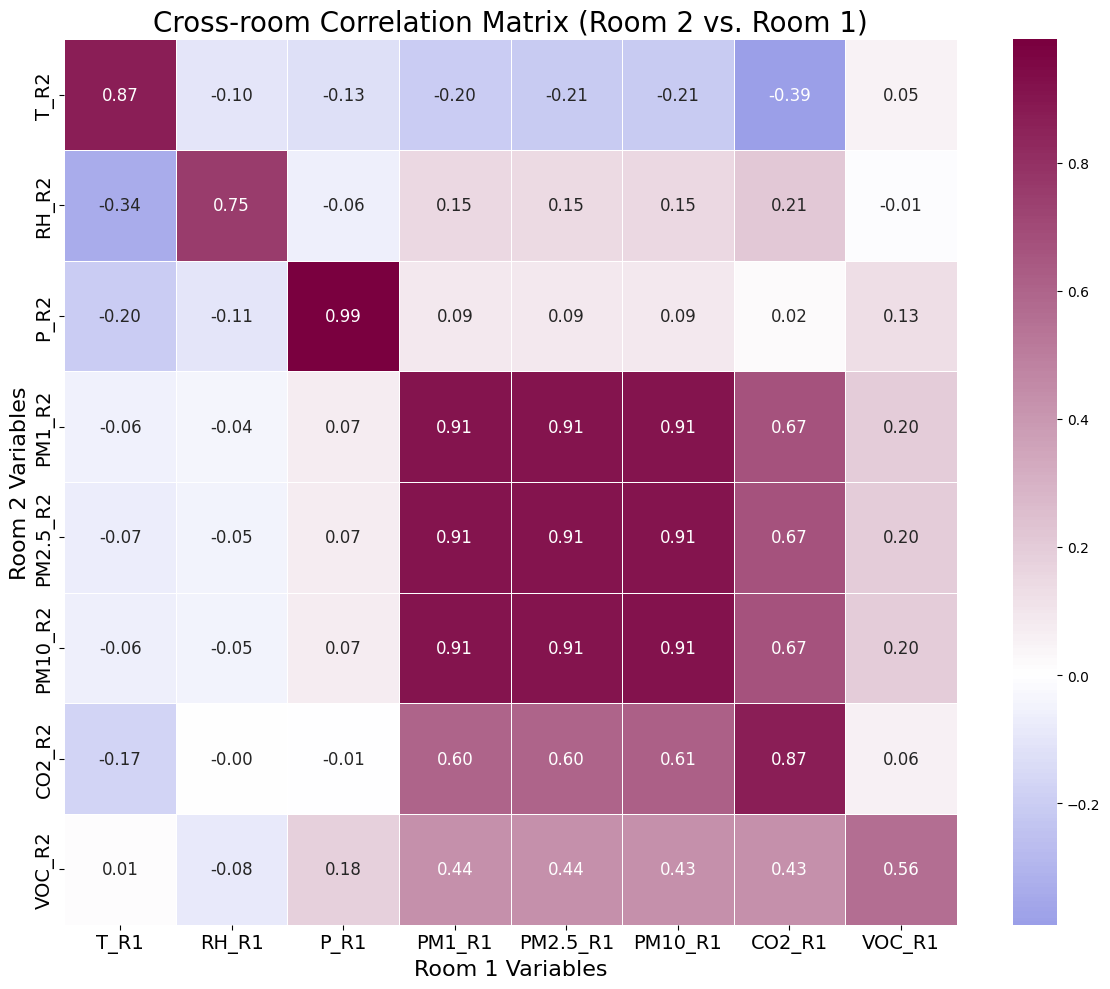

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data//room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

df2_raw = df2_raw.rename(columns={'PM2_5': 'PM2.5'})

vars1 = df1_raw.columns.drop('TIME').tolist()
vars2 = df2_raw.columns.drop('TIME').tolist()

df1_s = df1_raw.add_suffix('_R1').rename(columns={'TIME_R1': 'TIME'})
df2_s = df2_raw.add_suffix('_R2').rename(columns={'TIME_R2': 'TIME'})

merged = pd.merge(df1_s, df2_s, on='TIME')

r1_cols = [f"{v}_R1" for v in vars1]
r2_cols = [f"{v}_R2" for v in vars2]

full_corr = merged[r1_cols + r2_cols].corr(method='spearman')
cross_room_corr = full_corr.loc[r2_cols, r1_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(cross_room_corr, cmap=custom_cmap, annot=True, fmt=".2f", linewidths=.5, center=0, annot_kws={"size": 12})

plt.title('Cross-room Correlation Matrix (Room 2 vs. Room 1)', fontsize=20)
plt.xlabel('Room 1 Variables', fontsize=16)
plt.ylabel('Room 2 Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## Gore korelaciju medju sobama za parametre staviti ^ !!!!!!!!!! (izmenio 14.5.26. da bude samo R1 po x i R2 po y)
dole podeliti po periodima mirovanja i boravka

# Zakljucci za Pearsonovu cross-room korelaciju:


1. Veoma jaka korelacija PM frakcija između prostorija (PM1, PM2.5, PM10 > 0.85) sugeriše postojanje zajedničkog izvora aerosola ili efikasne vazdušne povezanosti između prostorija.

2. Srednje jaka cross-room korelacija CO₂ koncentracija (~0.79) sugeriše delimično zajednički ventilacioni režim uz lokalni uticaj prisustva korisnika.

3. Relativno slaba korelacija između CO₂ i PM koncentracija ukazuje da ljudsko disanje i resuspenzija čestica nisu nužno simultani procesi u residential indoor environments.

4. Povećanje korelacije CO₂–PM tokom perioda bez prisustva korisnika sugeriše dominantan uticaj spoljašnjih faktora i stabilnijih pozadinskih uslova.

5. Pad CO₂–PM korelacije tokom occupancy perioda ukazuje na kompleksnu i nelinearnu prirodu indoor aerosol dynamics.

6. Slaba povezanost VOC koncentracija između prostorija sugeriše prisustvo lokalizovanih izvora VOC emisija.

7. Negativna korelacija temperature i CO₂ može ukazivati na povećanu ventilaciju tokom toplijih perioda ili ponašanje korisnika povezano sa otvaranjem prozora.

8. Razlika između Pearson i potencijalne Spearman korelacije može ukazivati na prisustvo nelinearnih odnosa između indoor pollutants.

9. Visoka korelacija PM koncentracija između prostorija ukazuje na moguću migraciju aerosola kroz ventilacione ili difuzione procese.

sledeći korak za naučni rad:  
  - da li povećanje CO₂ u jednoj prostoriji prethodi rastu PM u drugoj,
  - da li ljudi u jednoj sobi utiču na drugu,
  - da li ventilacija prenosi aerosole.

  - Lagged correlation:
      - Umesto samo istovremene korelacije:

        proveriti korelaciju sa vremenskim pomakom.

        Na primer:

        CO₂ room1 u trenutku t
        PM2.5 room2 u trenutku t + 1h

        Ako dobijemo:

        jaku korelaciju sa delay-em,
        onda možemo diskutovati o:
        cirkulaciji vazduha,
        kašnjenju širenja polutanata,
        HVAC efektu,
        propagaciji aerosola.

  - Occupancy vs non-occupancy između soba:
      - Scenario A:
        visoki CO₂ spike
        prisutni ljudi
      - Scenario B:
        nizak CO₂
        prazna prostorija

        Pa uporedimo:

        da li sobe postaju sličnije kada nema ljudi,
        da li occupancy “lokalizuje” zagađenje,
        da li prazne sobe više prate outdoor uslove.

  - Indoor ↔ indoor vs indoor ↔ outdoor:
      - Ko je sličniji kome?

        Na primer:

          - ////////////////////////Korelacija	, Tumačenje
        - Room1 ↔ Room2 velika,	zajednički indoor uslovi
        - Room1 ↔ Outdoor velika,	dominantan spoljašnji uticaj
        - PM indoor ↔ outdoor jaka,	infiltracija spoljašnjeg zagađenja
        - CO₂ indoor ↔ outdoor slaba,	dominantan human occupancy

## Veoma bitna metodološka stvar!

Pošto koristimo vremenske serije:

 - klasična Pearson korelacija ponekad može da zavara zbog trendova.

Zato bi bilo dobro da probamo i:

  - Spearman correlation
  - rolling correlation
  - detrended correlation

Makar da pomenemo u diskusiji ograničenja Pearson metode.

Pearson meri:

linearnu povezanost.

Spearman meri:

monotonic relationship,
robusniji je na outliere,
bolji za environmental data.

Vrlo je moguće da:

Pearson bude slab,
a Spearman značajan.

To bi bio veoma dobar rezultat za diskusiju.

Dodatna ideja (veoma dobra za vizuelizaciju)

Napravimo:

Difference heatmap

Na primer:

corr_occupied - corr_unoccupied

i pokažemo:

koje korelacije opadaju kada su ljudi prisutni.

## High occupancy period Cross-room Pearsons correlation - from the 15th of August

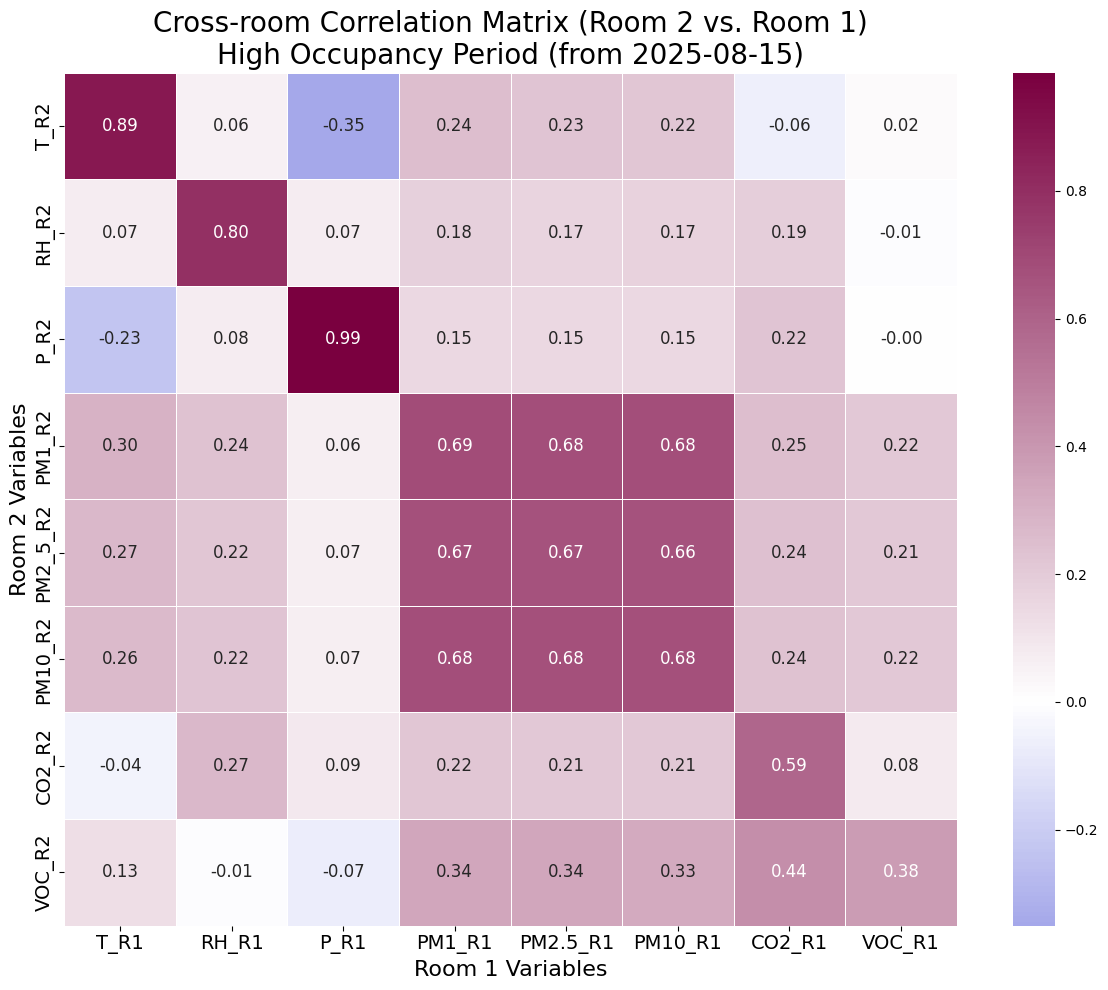

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

start_date_occupancy = '2025-08-15'
df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

df1_filtered = df1_raw[df1_raw['TIME'] >= start_date_occupancy].copy()
df2_filtered = df2_raw[df2_raw['TIME'] >= start_date_occupancy].copy()

df1_original_data_cols = df1_filtered.columns.drop('TIME').tolist()
df2_original_data_cols = df2_filtered.columns.drop('TIME').tolist()

df1_filtered = df1_filtered.add_suffix('_R1').rename(columns={'TIME_R1': 'TIME'})
df2_filtered = df2_filtered.add_suffix('_R2').rename(columns={'TIME_R2': 'TIME'})

merged = pd.merge(df1_filtered, df2_filtered, on='TIME')
r1_suffixed_cols = [f"{col}_R1" for col in df1_original_data_cols]
r2_suffixed_cols = [f"{col}_R2" for col in df2_original_data_cols]

full_corr = merged[r1_suffixed_cols + r2_suffixed_cols].corr()
cross_room_corr = full_corr.loc[r2_suffixed_cols, r1_suffixed_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(cross_room_corr, cmap=custom_cmap, annot=True, fmt=".2f", linewidths=.5, center=0, annot_kws={"size": 12})
plt.title(f'Cross-room Correlation Matrix (Room 2 vs. Room 1)\nHigh Occupancy Period (from {start_date_occupancy})', fontsize=20)
plt.xlabel('Room 1 Variables', fontsize=16)
plt.ylabel('Room 2 Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## High occupancy period Cross-room Pearsons correlation - from the 15th of August without the nightime samples


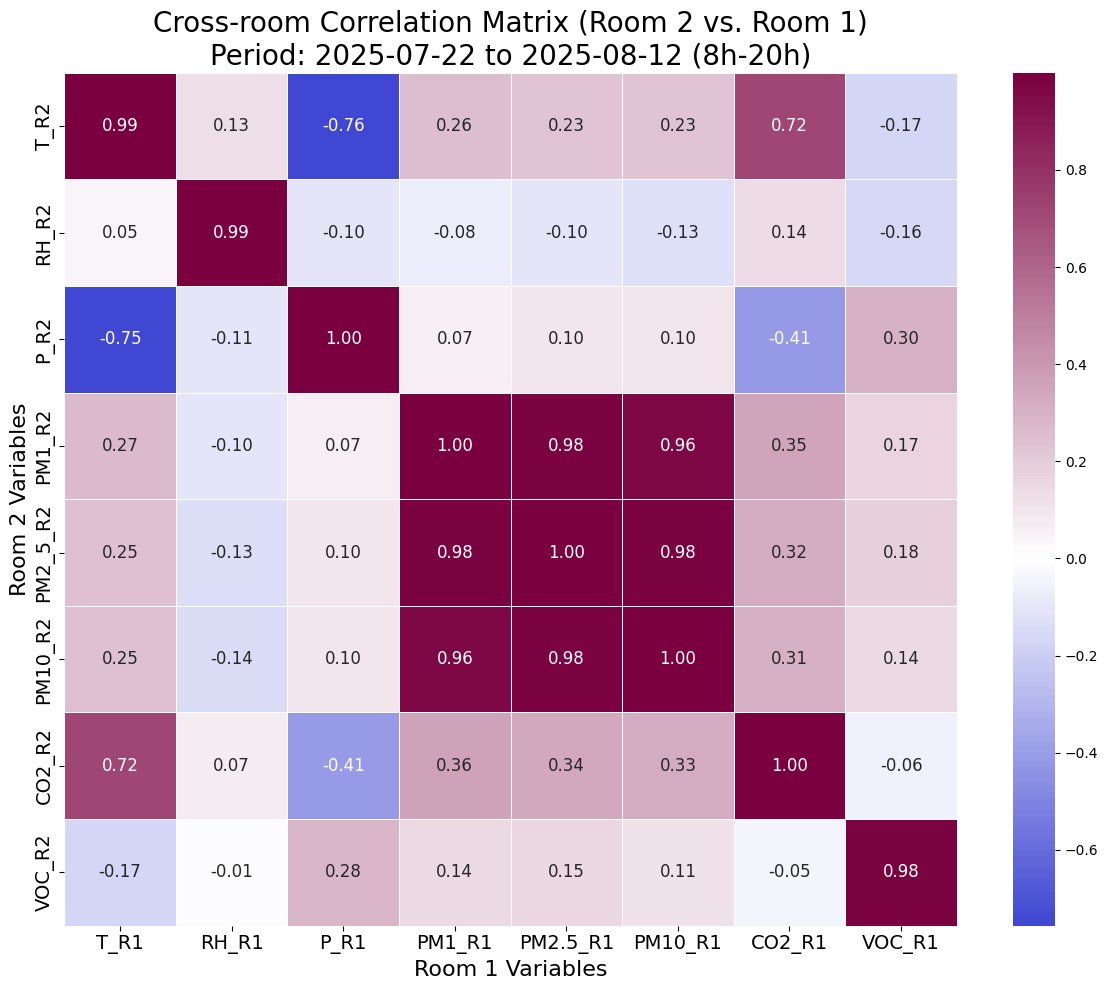

In [ ]:
start_date = '2025-07-22'
end_date = '2025-08-12'
start_hour_daytime = 8
end_hour_daytime = 20

# Standardized Colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

# Reload data
df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')
df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

# Filter
df1_f = df1_raw[(df1_raw['TIME'] >= start_date) & (df1_raw['TIME'] <= end_date) & (df1_raw['TIME'].dt.hour >= start_hour_daytime) & (df1_raw['TIME'].dt.hour <= end_hour_daytime)].copy()
df2_f = df2_raw[(df2_raw['TIME'] >= start_date) & (df2_raw['TIME'] <= end_date) & (df2_raw['TIME'].dt.hour >= start_hour_daytime) & (df2_raw['TIME'].dt.hour <= end_hour_daytime)].copy()

df1_cols = df1_f.columns.drop('TIME').tolist()
df2_cols = df2_f.columns.drop('TIME').tolist()

merged = pd.merge(df1_f.add_suffix('_R1').rename(columns={'TIME_R1':'TIME'}), df2_f.add_suffix('_R2').rename(columns={'TIME_R2':'TIME'}), on='TIME')

cross_room_corr = merged[[f'{c}_R1' for c in df1_cols] + [f'{c}_R2' for c in df2_cols]].corr().loc[[f'{c}_R2' for c in df2_cols], [f'{c}_R1' for c in df1_cols]]

plt.figure(figsize=(12, 10))
sns.heatmap(cross_room_corr, cmap=custom_cmap, annot=True, fmt=".2f", linewidths=.5, center=0, annot_kws={"size": 12})
plt.title(f'Cross-room Correlation Matrix (Room 2 vs. Room 1)\nPeriod: {start_date} to {end_date} ({start_hour_daytime}h-{end_hour_daytime}h)', fontsize=20)
plt.xlabel('Room 1 Variables', fontsize=16)
plt.ylabel('Room 2 Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## High occupancy period Cross-room Spearmans correlation - from the 15th of August without the nightime samples

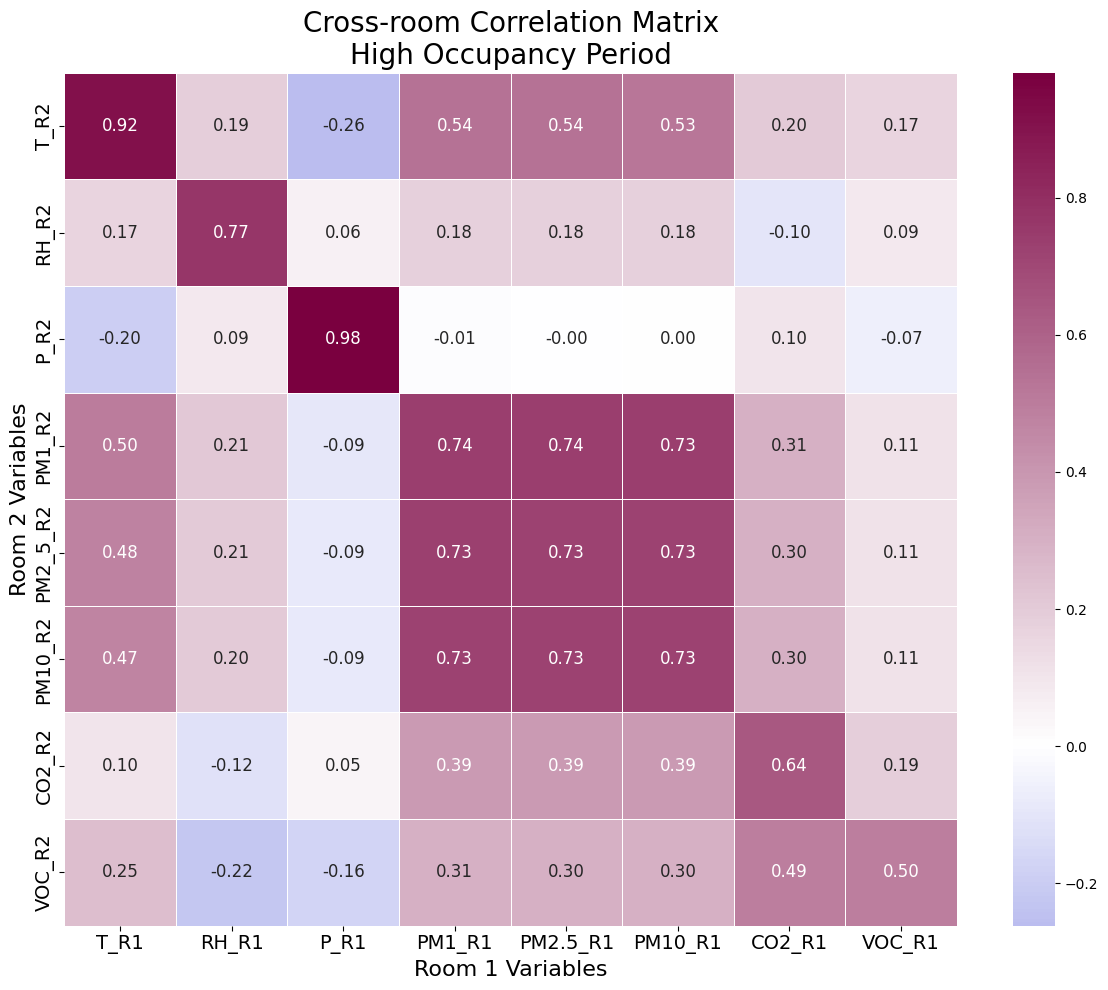

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])
start_date_occupancy = '2025-08-15'
start_hour_daytime, end_hour_daytime = 8, 20

df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')
df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

df1_f = df1_raw[(df1_raw['TIME'] >= start_date_occupancy) & (df1_raw['TIME'].dt.hour >= start_hour_daytime) & (df1_raw['TIME'].dt.hour <= end_hour_daytime)].copy()
df2_f = df2_raw[(df2_raw['TIME'] >= start_date_occupancy) & (df2_raw['TIME'].dt.hour >= start_hour_daytime) & (df2_raw['TIME'].dt.hour <= end_hour_daytime)].copy()

merged = pd.merge(df1_f.add_suffix('_R1').rename(columns={'TIME_R1':'TIME'}), df2_f.add_suffix('_R2').rename(columns={'TIME_R2':'TIME'}), on='TIME')
r1_cols, r2_cols = [f"{c}_R1" for c in df1_f.columns if c!='TIME'], [f"{c}_R2" for c in df2_f.columns if c!='TIME']

cross_room_corr = merged[r1_cols + r2_cols].corr(method='spearman').loc[r2_cols, r1_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(cross_room_corr, cmap=custom_cmap, annot=True, fmt=".2f", linewidths=.5, center=0, annot_kws={"size": 12})
plt.title(f'Cross-room Correlation Matrix\nHigh Occupancy Period', fontsize=20)
plt.xlabel('Room 1 Variables', fontsize=16)
plt.ylabel('Room 2 Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## Low occupancy period Cross-room Spearmans correlation - from the 15th of August without the nightime samples

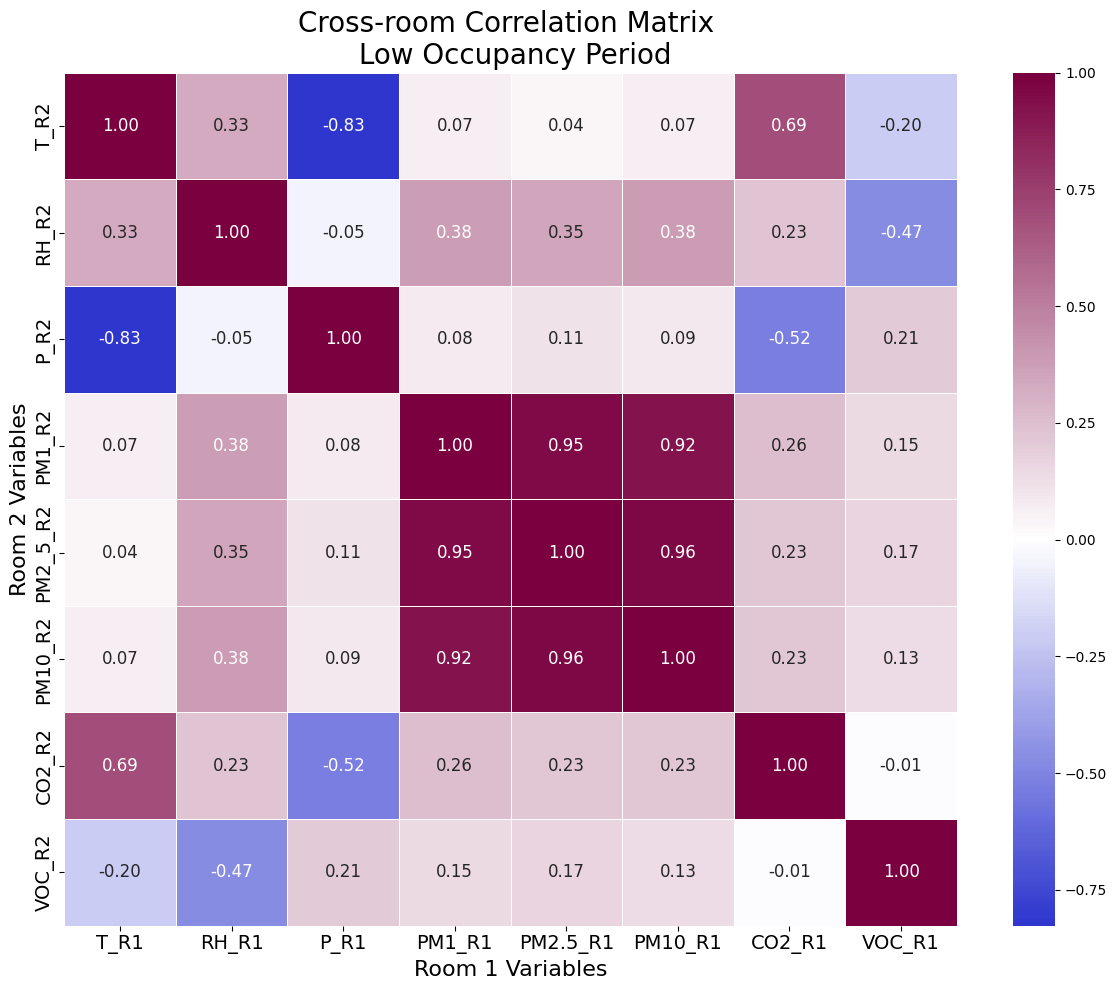

In [ ]:
custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", ["#020cc4", "#ffffff", "#7A003F"])

start_hour_daytime = 8
end_hour_daytime = 20
start_date_low_occupancy = '2025-07-22'
end_date_low_occupancy = '2025-08-10'

df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')
df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

df1_f = df1_raw[(df1_raw['TIME'] >= start_date_low_occupancy) & (df1_raw['TIME'] <= end_date_low_occupancy) & (df1_raw['TIME'].dt.hour >= start_hour_daytime) & (df1_raw['TIME'].dt.hour <= end_hour_daytime)].copy()
df2_f = df2_raw[(df2_raw['TIME'] >= start_date_low_occupancy) & (df2_raw['TIME'] <= end_date_low_occupancy) & (df2_raw['TIME'].dt.hour >= start_hour_daytime) & (df2_raw['TIME'].dt.hour <= end_hour_daytime)].copy()

merged = pd.merge(df1_f.add_suffix('_R1').rename(columns={'TIME_R1':'TIME'}), df2_f.add_suffix('_R2').rename(columns={'TIME_R2':'TIME'}), on='TIME')
sample_size = len(merged)
r1_cols = [f"{c}_R1" for c in ['T', 'RH', 'P', 'PM1', 'PM2.5', 'PM10', 'CO2', 'VOC'] if f"{c}_R1" in merged.columns]
r2_cols = [f"{c}_R2" for c in ['T', 'RH', 'P', 'PM1', 'PM2_5', 'PM10', 'CO2', 'VOC'] if f"{c}_R2" in merged.columns]

cross_room_corr = merged[r1_cols + r2_cols].corr(method='spearman').loc[r2_cols, r1_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(cross_room_corr, cmap=custom_cmap, annot=True, fmt=".2f", linewidths=.5, center=0, annot_kws={"size": 12})
plt.title(f'Cross-room Correlation Matrix \n Low Occupancy Period', fontsize=20)
plt.xlabel('Room 1 Variables', fontsize=16)
plt.ylabel('Room 2 Variables', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

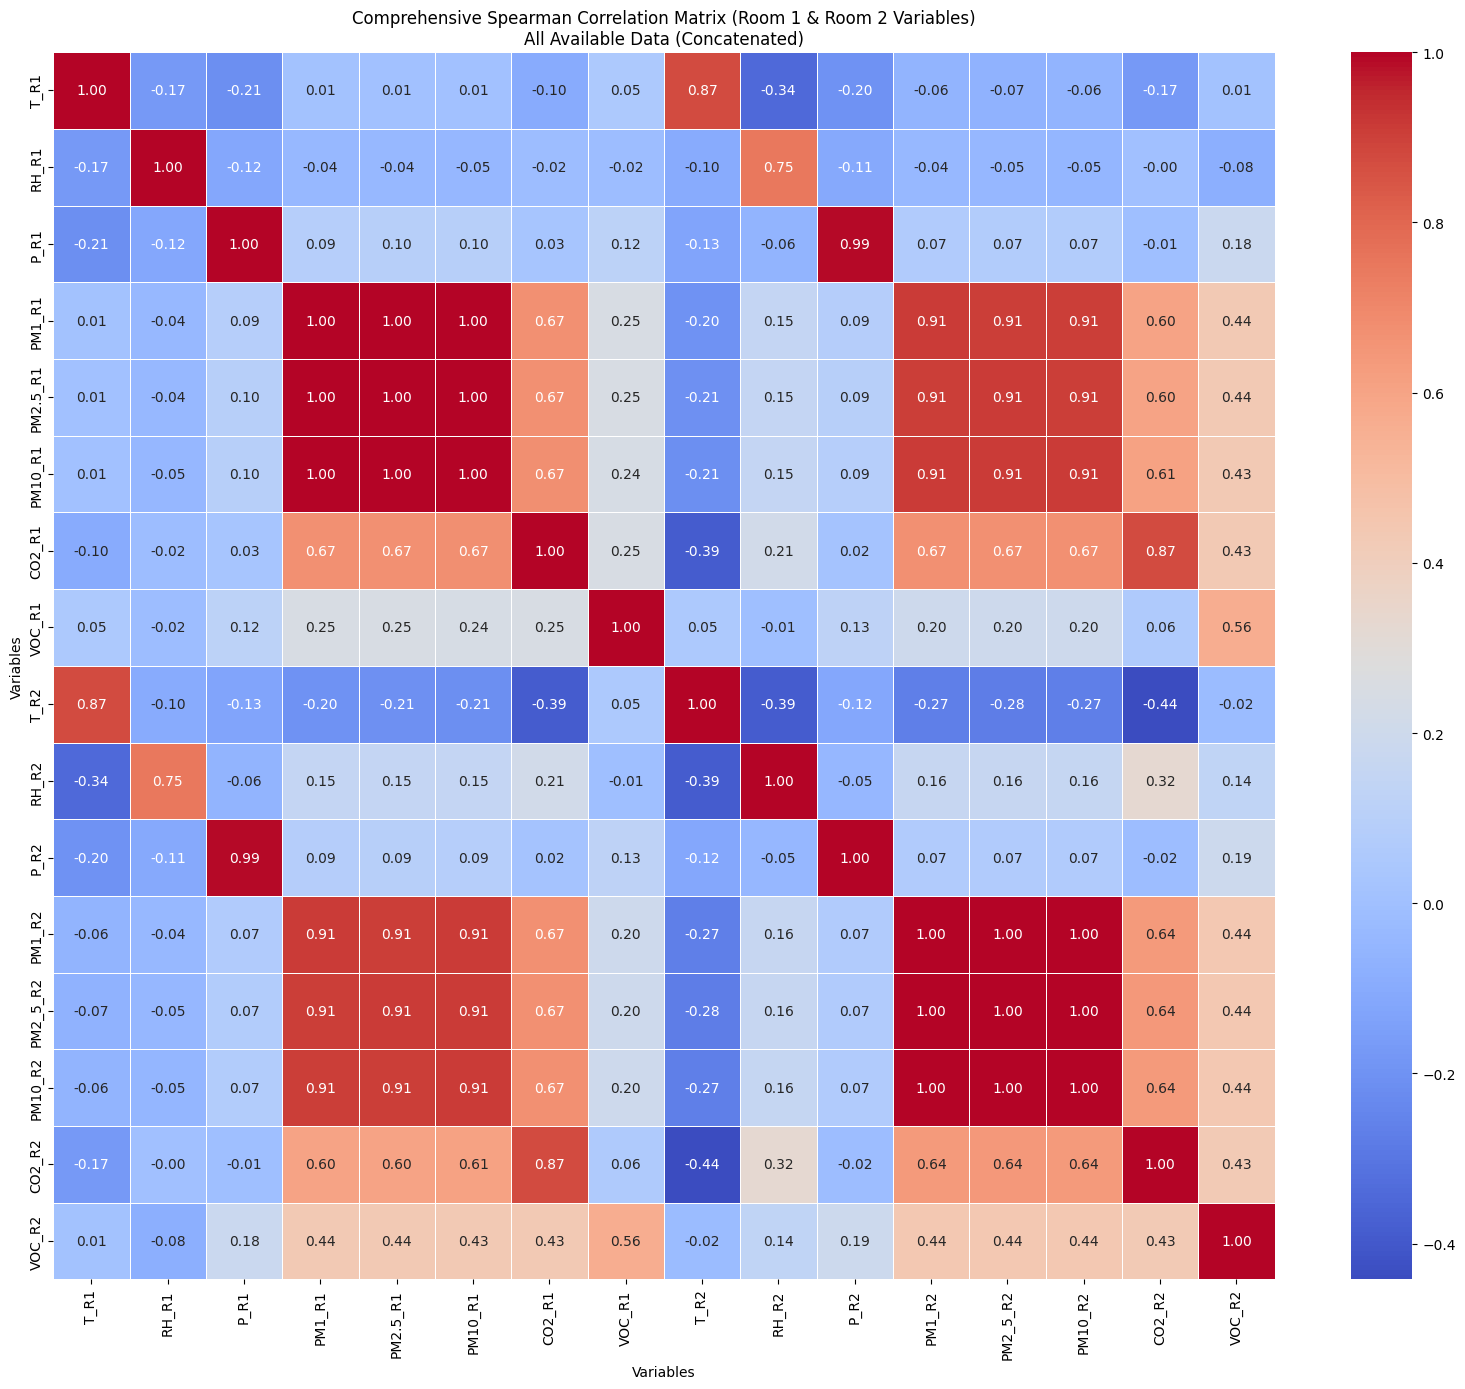

In [ ]:
df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

# Ensure TIME columns are datetime for the raw data
df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])


# --- Comprehensive Correlation Matrix for All Data (Concatenated Data) ---

# Create copies of raw dataframes for full analysis to avoid modifying original 'df1_raw'/'df2_raw'
df1_full = df1_raw.copy()
df2_full = df2_raw.copy()

# Get original non-TIME column names before suffixing
df1_full_data_cols = df1_full.columns.drop('TIME').tolist()
df2_full_data_cols = df2_full.columns.drop('TIME').tolist()

# Add suffixes to columns to differentiate between rooms
df1_full = df1_full.add_suffix('_R1')
df2_full = df2_full.add_suffix('_R2')

# Rename the 'TIME' column back for merging
df1_full = df1_full.rename(columns={'TIME_R1': 'TIME'})
df2_full = df2_full.rename(columns={'TIME_R2': 'TIME'})

# Merge dataframes on the 'TIME' column (using an inner join to only keep common timestamps)
merged_full_data = pd.merge(df1_full, df2_full, on='TIME', how='inner')

# Identify all suffixed data columns for the correlation matrix
all_suffixed_cols = [
    f"{col}_R1" for col in df1_full_data_cols if f"{col}_R1" in merged_full_data.columns
] + [
    f"{col}_R2" for col in df2_full_data_cols if f"{col}_R2" in merged_full_data.columns
]

# Calculate the full Spearman correlation matrix
overall_corr = merged_full_data[all_suffixed_cols].corr(method='spearman')

# Plotting the comprehensive correlation matrix
plt.figure(figsize=(16, 14)) # Adjust figure size for better readability of a larger matrix
sns.heatmap(overall_corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.title('Comprehensive Spearman Correlation Matrix (Room 1 & Room 2 Variables)\nAll Available Data (Concatenated)')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Koja je mera korelacije medju sobama - da li su izolovana merenja - uticu aktivnosti vise

Istraziti u kakvom su odnosu sobe
. Na koji faktor najvise utice ljudska aktivnost i u kom odnosu. Da li postoji neka merljiva velicina koliko je ljudska aktivnost uticala na promenu.
Sem ljudskog faktora na korelaciju uticu i drugi faktori(bez ljudi korelacija nije 1  nego 0.89)

# !! Matrica razlika, statisticka znacajnost(vrv ne), vizualizovati nekako?, boxplot

matrica razlika oduzimamo vrednosti od vrednosti nakon oduzimamo vrednosti tokom odmora,

test statisticke znacajnosti, za svaki par korelacija da li imaju preveliku razliku, potvrditi da ne prelazi neku granicu, da nije doslo do anomalija pa da je zato preterano razlicita.

https://www.mdpi.com/1424-8220/24/13/4052

materials cilj dataseta je - , opisati sve sto postoji u datasetu samo naglasiti sta smo koristili
(na pocetku subsekcije pisati sazetak sta je u toj sekciji)
methods -  cilj nase analize dataseta je,m etodologija pristpa ovog rada, stat anazila, vizuelnte metode, hipoteze, primenjene te i te metode, koristili python...,

# Uzahir beleske(petak):

// razlicite ili iste sredine, aktivnosti u jednoj uticu na kvalitet vazduha u drugoj, sredina kao parametar koji suprotstavljamo

zakljucak - s obzirom da je indoor zatvorena sredina u kojoj se meri AQ i ljudski faktor je jedan od najznacajnijih, gledano na velicine ljudski faktor ima najmanji utican na sledece faktore -

najveca razlika kada je korelacija slabija
na sta najmanje utice covekovo ponasanje u zatvorenoj sredini
tj. slaba korelacija izmedju soba = veliki uticaj covekovog prisustva i aktivnosti

najmanji uticaj - najveca korelacija - pritisak, temperatura

srednja - vlaznost - aktivnosti uticu najvise vetrenje itd

najveci uticaj - tamo gde pada korelacija - voc, pm, co2

razlicite aktivnosti koje se desavaju u sobama, sto vise uticu na menjanje parametra to je slabija korelacija, pogledati glavnu dijagonalu

da li postoji neka merljiva velicina koliko je ljudska aktivnost utice na promenu - porediti period bez i sa aktivnostima - naci nacin koliko % ljudska aktivnost utice - lep zakljucak :))


## The Synchronization Index (SI)

Visok SI znači:

sobe se ponašaju veoma slično
sistem je stabilan
promene su sinhronizovane

Nizak SI znači:

sobe se ponašaju nezavisnije
više lokalnih perturbacija
više haotičnosti

In [ ]:
start_date = '2025-08-15'
start_hour = 8
end_hour = 20

df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

df1_f = df1_raw[(df1_raw['TIME'] >= start_date) &
                (df1_raw['TIME'].dt.hour >= start_hour) &
                (df1_raw['TIME'].dt.hour <= end_hour)].copy()

df2_f = df2_raw[(df2_raw['TIME'] >= start_date) &
                (df2_raw['TIME'].dt.hour >= start_hour) &
                (df2_raw['TIME'].dt.hour <= end_hour)].copy()

df1_f = df1_f.rename(columns={'PM2.5': 'PM2_5'})
df2_f = df2_f.rename(columns={'PM2.5': 'PM2_5'})

df1_f = df1_f.add_suffix('_R1').rename(columns={'TIME_R1': 'TIME'})
df2_f = df2_f.add_suffix('_R2').rename(columns={'TIME_R2': 'TIME'})
merged = pd.merge(df1_f, df2_f, on='TIME')

vars_to_watch = ['PM1', 'PM2_5', 'PM10', 'CO2', 'VOC', 'T', 'RH', 'P']
correlations = []

print(f"Spearman correlations (Room 1 vs Room 2) for period {start_date} to end, during daytime:")
print("-" * 60)

for var in vars_to_watch:
    col1 = f"{var}_R1"
    col2 = f"{var}_R2"
    if col1 in merged.columns and col2 in merged.columns:
        rho = merged[[col1, col2]].corr(method='spearman').iloc[0, 1]
        correlations.append(rho)
        print(f"{var:10} | r = {rho:.4f}")

if correlations:
    abs_sum = sum(abs(r) for r in correlations)
    n = len(correlations)
    si = abs_sum / n

    print("-" * 60)
    print(f"Number of correlations (N): {n}")
    print(f"Stability Index (SI): {si:.4f}")
else:
    print("No matching columns found to calculate correlations.")

Spearman correlations (Room 1 vs Room 2) for period 2025-08-15 to end, during daytime:
------------------------------------------------------------
PM1        | r = 0.7373
PM2_5      | r = 0.7293
PM10       | r = 0.7253
CO2        | r = 0.6387
VOC        | r = 0.4955
T          | r = 0.9165
RH         | r = 0.7708
P          | r = 0.9823
------------------------------------------------------------
Number of correlations (N): 8
Stability Index (SI): 0.7495


In [ ]:
start_date = '2025-07-20'
end_date = '2025-08-10'
start_hour = 8
end_hour = 20

df1_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv')
df2_raw = pd.read_csv('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv')

df1_raw['TIME'] = pd.to_datetime(df1_raw['TIME'])
df2_raw['TIME'] = pd.to_datetime(df2_raw['TIME'])

df1_f = df1_raw[(df1_raw['TIME'] >= start_date) &
                (df1_raw['TIME'] <= end_date) &
                (df1_raw['TIME'].dt.hour >= start_hour) &
                (df1_raw['TIME'].dt.hour <= end_hour)].copy()

df2_f = df2_raw[(df2_raw['TIME'] >= start_date) &
                (df2_raw['TIME'] <= end_date) &
                (df2_raw['TIME'].dt.hour >= start_hour) &
                (df2_raw['TIME'].dt.hour <= end_hour)].copy()

df1_f = df1_f.rename(columns={'PM2.5': 'PM2_5'})
df2_f = df2_f.rename(columns={'PM2.5': 'PM2_5'})

df1_f = df1_f.add_suffix('_R1').rename(columns={'TIME_R1': 'TIME'})
df2_f = df2_f.add_suffix('_R2').rename(columns={'TIME_R2': 'TIME'})
merged = pd.merge(df1_f, df2_f, on='TIME')

vars_to_watch = ['PM1', 'PM2_5', 'PM10', 'CO2', 'VOC', 'T', 'RH', 'P']
correlations = []

print(f"Spearman correlations (Room 1 vs Room 2) for period {start_date} to {end_date}, during daytime:")
print("-" * 60)

for var in vars_to_watch:
    col1 = f"{var}_R1"
    col2 = f"{var}_R2"
    if col1 in merged.columns and col2 in merged.columns:
        rho = merged[[col1, col2]].corr(method='spearman').iloc[0, 1]
        correlations.append(rho)
        print(f"{var:10} | r = {rho:.4f}")

if correlations:
    abs_sum = sum(abs(r) for r in correlations)
    n = len(correlations)
    si = abs_sum / n

    print("-" * 60)
    print(f"Number of correlations (N): {n}")
    print(f"Stability Index (SI): {si:.4f}")
else:
    print("No matching columns found to calculate correlations.")

Spearman correlations (Room 1 vs Room 2) for period 2025-07-20 to 2025-08-10, during daytime:
------------------------------------------------------------
PM1        | r = 0.9596
PM2_5      | r = 0.9608
PM10       | r = 0.9627
CO2        | r = 0.9522
VOC        | r = 0.9774
T          | r = 0.9990
RH         | r = 0.9998
P          | r = 0.9991
------------------------------------------------------------
Number of correlations (N): 8
Stability Index (SI): 0.9763


### Comparative Analysis: Synchronization Index (SI)
Human impact quantification

In [ ]:

def calculate_si(df1_path, df2_path, start_date, end_date=None, daytime_only=True):
    # Load and prep
    d1 = pd.read_csv(df1_path)
    d2 = pd.read_csv(df2_path)
    d1['TIME'] = pd.to_datetime(d1['TIME'])
    d2['TIME'] = pd.to_datetime(d2['TIME'])

    # Rename for alignment
    d1 = d1.rename(columns={'PM2.5': 'PM2_5'})
    d2 = d2.rename(columns={'PM2.5': 'PM2_5'})

    # Filter dates
    mask1 = (d1['TIME'] >= start_date)
    mask2 = (d2['TIME'] >= start_date)
    if end_date:
        mask1 &= (d1['TIME'] <= end_date)
        mask2 &= (d2['TIME'] <= end_date)

    f1, f2 = d1[mask1].copy(), d2[mask2].copy()

    # Filter daytime
    if daytime_only:
        f1 = f1[(f1['TIME'].dt.hour >= 8) & (f1['TIME'].dt.hour <= 20)]
        f2 = f2[(f2['TIME'].dt.hour >= 8) & (f2['TIME'].dt.hour <= 20)]

    merged = pd.merge(f1.add_suffix('_R1').rename(columns={'TIME_R1':'TIME'}),
                      f2.add_suffix('_R2').rename(columns={'TIME_R2':'TIME'}), on='TIME')

    vars_to_watch = ['PM1', 'PM2_5', 'PM10', 'CO2', 'VOC', 'T', 'RH', 'P']
    corrs = []
    for v in vars_to_watch:
        if f'{v}_R1' in merged.columns and f'{v}_R2' in merged.columns:
            rho = merged[[f'{v}_R1', f'{v}_R2']].corr(method='spearman').iloc[0, 1]
            corrs.append(rho)

    return np.mean(np.abs(corrs)) if corrs else 0

si_low = calculate_si('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv', '/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv', '2025-07-22', '2025-08-10')
si_high = calculate_si('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv', '/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv', '2025-08-15')

print(f"Synchronization Index (Low Occupancy): {si_low:.4f}")
print(f"Synchronization Index (High Occupancy): {si_high:.4f}")
print(f"Difference (Decoupling Effect): {si_low - si_high:.4f}")

Synchronization Index (Low Occupancy): 1.0000
Synchronization Index (High Occupancy): 0.7495
Difference (Decoupling Effect): 0.2505


# Fisher z-transformation?

# Relative change (%)

Relative changes in correlation strength were used to estimate the impact of human presence on indoor pollutant dynamics

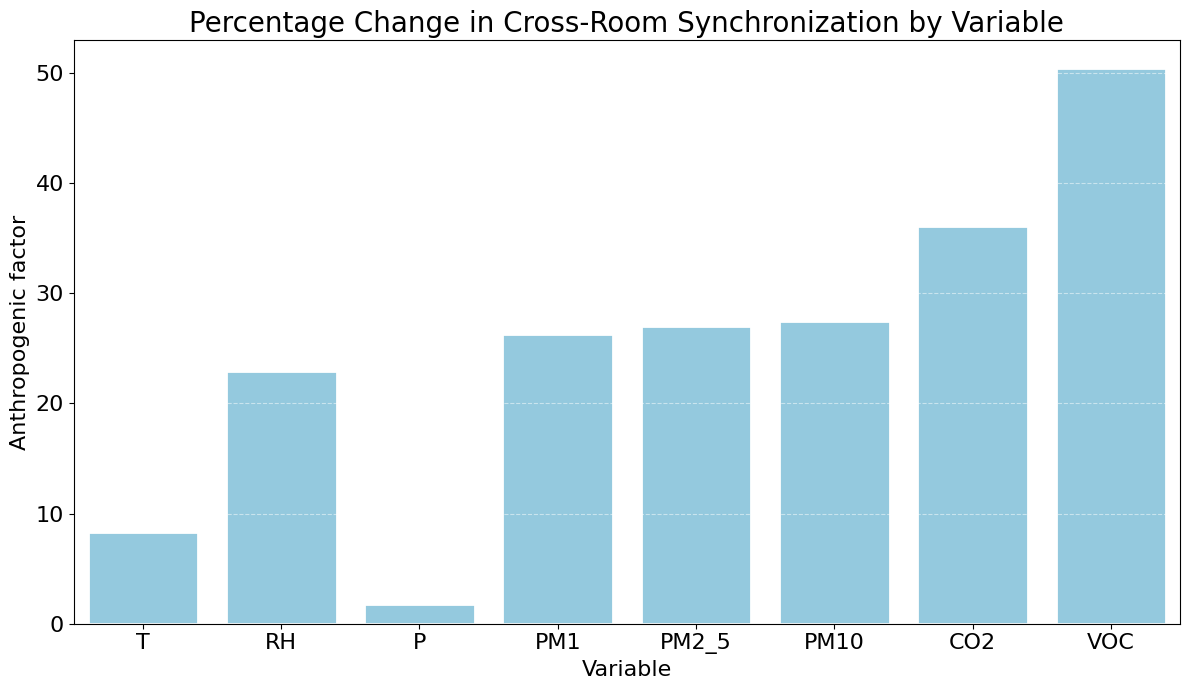

In [ ]:
def get_diagonal_corrs(df1_path, df2_path, start_date, end_date=None):
    d1 = pd.read_csv(df1_path)
    d2 = pd.read_csv(df2_path)
    d1['TIME'] = pd.to_datetime(d1['TIME'])
    d2['TIME'] = pd.to_datetime(d2['TIME'])
    d1 = d1.rename(columns={'PM2.5': 'PM2_5'})
    d2 = d2.rename(columns={'PM2.5': 'PM2_5'})

    mask1 = (d1['TIME'] >= start_date)
    mask2 = (d2['TIME'] >= start_date)
    if end_date:
        mask1 &= (d1['TIME'] <= end_date)
        mask2 &= (d2['TIME'] <= end_date)

    f1, f2 = d1[mask1].copy(), d2[mask2].copy()
    f1 = f1[(f1['TIME'].dt.hour >= 8) & (f1['TIME'].dt.hour <= 20)]
    f2 = f2[(f2['TIME'].dt.hour >= 8) & (f2['TIME'].dt.hour <= 20)]

    merged = pd.merge(f1.add_suffix('_R1').rename(columns={'TIME_R1':'TIME'}),
                      f2.add_suffix('_R2').rename(columns={'TIME_R2':'TIME'}), on='TIME')

    vars_to_watch = ['T', 'RH', 'P', 'PM1', 'PM2_5', 'PM10', 'CO2', 'VOC']
    diag_corrs = {}
    for v in vars_to_watch:
        if f'{v}_R1' in merged.columns and f'{v}_R2' in merged.columns:
            rho = merged[[f'{v}_R1', f'{v}_R2']].corr(method='spearman').iloc[0, 1]
            diag_corrs[v] = rho
    return diag_corrs

corrs_unocc = get_diagonal_corrs('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv', '/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv', '2025-07-22', '2025-08-10')
corrs_occ = get_diagonal_corrs('/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room1_hourly.csv', '/content/drive/MyDrive/faks_sept_2026/veštačka_inteligencija/dataset/air_clair/data/room2_hourly.csv', '2025-08-15')

results = []
for var in corrs_unocc:
    r_un = corrs_unocc[var]
    r_oc = corrs_occ[var]
    perc_change = ((r_un - r_oc) / r_un) * 100
    results.append({'Variable': var, 'r_unoccupied': round(r_un, 4), 'r_occupied': round(r_oc, 4), '% Change (Decoupling)': round(perc_change, 2)})

summary_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sns.barplot(x='Variable', y='% Change (Decoupling)', data=summary_df, color='skyblue', edgecolor='white', linewidth=2)

plt.title('Percentage Change in Cross-Room Synchronization by Variable', fontsize=20)
plt.xlabel('Variable', fontsize=16)
plt.ylabel('Anthropogenic factor', fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=16)
plt.yticks(fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='white')
plt.tight_layout()
plt.show()

In [ ]:
styled_summary_df = summary_df.style \
    .set_properties(**{'font-size': '14pt', 'text-align': 'right', 'background-color': 'skyblue', 'color': 'black'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '16pt'), ('text-align', 'center'), ('background-color', 'skyblue'), ('color', 'black'), ('border', '1px solid white')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#ACE5EE')]}
    ]) \
    .hide(axis='index')
display(styled_summary_df)

Variable,r_unoccupied,r_occupied,% Change (Decoupling)
T,1.000000,0.916500,8.350000
RH,1.000000,0.770800,22.920000
P,1.000000,0.982300,1.770000
PM1,1.000000,0.737300,26.270000
PM2_5,1.000000,0.729300,27.070000
PM10,1.000000,0.725300,27.470000
CO2,1.000000,0.638700,36.130000
VOC,1.000000,0.495500,50.450000


za dalje
klasifikacija neka moze da se uvede kao qc? tj validni i nevalidni podaci.
imamo vec mape moze se koristiti za treniranje, moze cak i da se spoji na dataset sa vrednostima -- pitati uzahira za nepreciscene podatke ? svakako moze i ovako ali bi to bilo tacnije

regresija na sta? mozda da predvidja kretanja vrednosti neka? kao ksenija sto je radila alert sistem? da prepozna kada ce porasti i biti nezdravo da se unapred proluftira? IOT SISTEM smart house ??? zapravo kul